# my first attempt at SFC

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd
import pickle as pk

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
import bhv_utils as bhv
import lfp_utils as lu
from bootstrap_method import *
import population_utils as pu

import sfc_utils as sfc


2025-10-01 11:17:16.206894: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-01 11:17:16.215278: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-01 11:17:16.224632: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-01 11:17:16.227413: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-01 11:17:16.234952: I tensorflow/core/platform/cpu_feature_guar

In [2]:
delay = 400
condn_phrase = 'delay'
condn_num = delay

# condn_key = f'{condn_phrase}{condn_num}'

In [3]:
# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/'
model_dirs = ld.get_immediate_subdirs(all_models_dir)

theta4_dirs = [m for m in model_dirs if '4.0' in m] # 4Hz models only
# theta8_dirs = [m for m in model_dirs if '8.0' in m] # 8Hz models only

print(f'Number of 4Hz models: {len(theta4_dirs)}')

perfs = []
for model_name in theta4_dirs:
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    perfs.append(np.mean(trial_perfs))
    print(f'Model {model_name}, performance: {np.mean(trial_perfs):.2f}')

Number of 4Hz models: 22
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038, performance: 0.85
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_135100, performance: 0.98
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_122821, performance: 0.99
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_141248, performance: 0.56
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121726, performance: 0.97
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121802, performance: 0.96
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140736, performance: 0.72
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134559, performance: 0.91
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134527, performance: 0.84
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121653, performance: 0.94
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121450, performance: 1.00
Model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025

## try 1 model

In [4]:
# choose a model to visualize for now
model_name = theta4_dirs[0]
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
print(data_files)

['/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038/bhv_dict_delay400.pkl', '/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038/bhv_dict_delay400_lfp_inh0.pkl', '/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038/neural_dict_delay400_lfp_inh0.pkl', '/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038/bhv_dict_delay400_lfp_exc0.pkl', '/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038/neural_dict_delay400_stimon100.pkl', '/home/nuttidalab/Documents/renee/lfp_input_mo

In [5]:
# neural data
lfp_data, spike_df, _ = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                                  load_LFP=True, load_spikes=True, load_rates=False,
                                                  all_models_dir=all_models_dir)

# behavioral data
trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)

# timing data
_,_, fs_dict = ld.load_timing_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
times_fs, times_real, fs_dict = ld.get_times_dict('ds', condn_phrase, condn_num, model_name=model_name, all_models_dir=all_models_dir)

In [58]:
times_fs

{'stim1_on': 255.0,
 'stim1_off': 505.0,
 'stim2_on': 2505.0,
 'stim2_off': 2755.0,
 'T': 3255.0,
 'delay': 2000.0,
 'stim_dur': 250.0,
 'fs': 1000}

In [7]:
lfp_data.shape

(3255, 200, 1000)

In [6]:
spike_df.head()

,cell_id,trial_id,cell_type,spk_times,model_name,delay
0,0,0,exc,[0.0],Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_...,400
1,1,0,inh,"[4832.0, 6212.0, 7102.0, 10750.0, 11267.0, 117...",Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_...,400
2,2,0,exc,[0.0],Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_...,400
3,3,0,exc,"[0.0, 15692.0, 20507.0, 41119.0, 64713.0]",Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_...,400
4,4,0,inh,"[195.0, 2337.0, 2942.0, 3754.0, 4767.0, 5767.0...",Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_...,400


In [8]:
lfp = np.mean(lfp_data, axis=1) # now time x trials, bc averaged over all neurons
lfp.shape

(3255, 1000)

In [6]:
fs_ds = int(fs_dict['ds'])
fs_rate = int(fs_dict['rate'])
fs_spk = int(fs_dict['spk'])

power, freqs, phase = lu.compute_lfp_power(np.mean(lfp_data, axis=1).T, fs=fs_ds) # average across neurons. power is (n_trials, n_freqs, n_times)
bandpower, band_sem = lu.calc_band_power(power, freqs, [4], baseline_times=[int(10/fs_rate*fs_ds), int(50/fs_rate*fs_ds)])

print(power.shape, freqs.shape, phase.shape)

(1000, 40, 3255) (40,) (1000, 40, 3255)


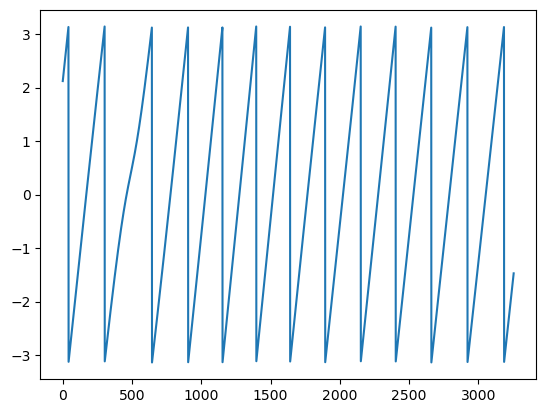

In [ ]:
plt.plot(phase[0, 0, :].T)


#### PLV steps

- For each trial, you compute PLV
- Then average across the trials. 
    - Here you can divide into the conditions that you are interested in comparing. So PLV average across correct trials and incorrect trials
- Next, you repeat above but this time shuffle spike times within each trial and then compute "null" average PLV for correct and incorrect conditions

In [7]:
from scipy.stats import circmean, circstd

def get_neuron_sfc(neuron_df, lfp_phase, fs_spk, fs_lfp, times_fs, threshold=2):
    """
    Compute spike-field coupling for a single neuron. Focus only on delay period.
    neuron_df: DataFrame (spike_df) for a single neuron)
    lfp_phase: array of shape (n_trials, n_times) with LFP phase values
    threshold: threshold in Hertz for number of spikes during delay period to include neuron
    """
    
    n_trials, n_times = lfp_phase.shape
    spike_trial_plvs = np.zeros(n_trials) # PLV for each trial
    spike_trial_phases = np.zeros(n_trials) # mean phase for each trial
    n_trial_spikes = np.zeros(n_trials) # number of spikes in each trial
    
    i = 0
    for _, row in neuron_df.iterrows(): # iterate over trials for this neuron
        spk_times = np.round(row['spk_times'] * fs_lfp / fs_spk).astype(int) # convert spike times to LFP time indices
        trial_id = row['trial_id']
        
        # focus only on delay period
        spk_times = spk_times[(spk_times >= times_fs['stim1_off']) & (spk_times <= times_fs['stim2_on'])]
        n_trial_spikes[i] = len(spk_times)
        
        # filter by spike threshold
        if n_trial_spikes[i] < (threshold * (times_fs['stim2_on'] - times_fs['stim1_off']) / fs_lfp): 
            spike_trial_phases[i] = np.nan
            spike_trial_plvs[i] = np.nan
            i += 1
            continue
        
        # get phase values at these spike times in this trial
        phase_values = lfp_phase[trial_id, spk_times]
        spike_trial_phases[i] = circmean(phase_values, high=np.pi, low=-np.pi) # mean phase for this trial
        spike_trial_plvs[i] = np.abs(np.mean(np.exp(1j * phase_values))) # PLV for this trial
        
        i += 1

    return spike_trial_phases, spike_trial_plvs, n_trial_spikes

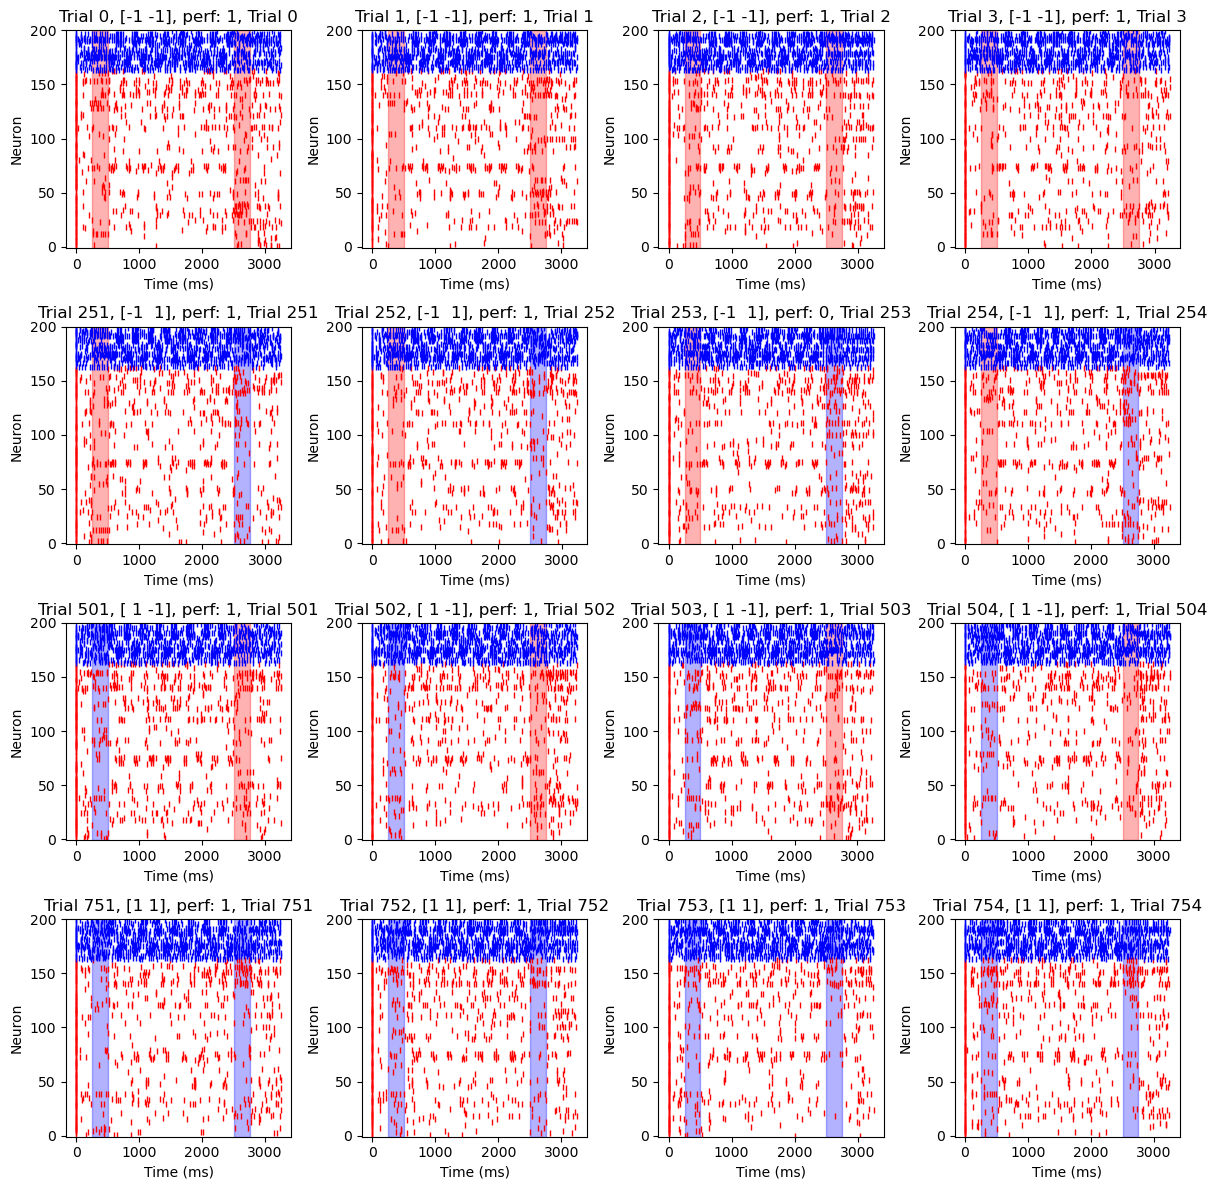

In [70]:
# plot 16 random trials, sort using the sort from the first trial (-1/-1)

importlib.reload(sn)

trial_ids = [0, 1, 2, 3, 251, 252, 253, 254, 501, 502, 503, 504, 751, 752, 753, 754]
fig, ax = plt.subplots(4, 4, figsize=(12, 12))


for i, trial_id in enumerate(trial_ids):
    trial_df = spike_df[spike_df['trial_id'] == trial_id]
    
    ax_i = np.unravel_index(i, (4, 4))
    sn.plot_trial_raster(trial_df, condn_phrase, condn_num, ax=ax[ax_i], title=f'Trial {trial_id}', all_models_dir=all_models_dir)
plt.tight_layout()
plt.show()

In [69]:
(times_fs['stim2_on'] - times_fs['stim1_off']) / fs_ds

2.0

In [34]:
def get_null_sfc(n_trial_spikes, lfp_phase, times_fs, n_shuffles=100):
    # n_trial_spikes is (trials x 1) array of number of spikes in each trial
    # lfp_phase is (trials x time) array of LFP phase values
    # n_shuffles is number of shuffles to perform for null distribution
    
    n_trials = len(n_trial_spikes)
    null_trial_plvs = np.zeros((n_trials, n_shuffles)) # null PLVs for each trial and shuffle
    null_trial_meanphases = np.zeros((n_trials, n_shuffles)) # null mean phases for each trial and shuffle
    
    for tr in range(n_trials):
        n_spikes = int(n_trial_spikes[tr])
        if n_spikes <= 1:
            null_trial_plvs[tr, :] = np.nan
            null_trial_meanphases[tr, :] = np.nan
            continue
        for s in range(n_shuffles):
            shuffled_spk_times = np.random.choice(np.arange(times_fs['stim1_off'], times_fs['stim2_on']), size=n_spikes, replace=False).astype(int) # only generate during delay period
            shuffled_phase_values = lfp_phase[tr, shuffled_spk_times]
            null_trial_plvs[tr, s] = np.abs(np.mean(np.exp(1j * shuffled_phase_values))) # PLV for this shuffle
            null_trial_meanphases[tr, s] = circmean(shuffled_phase_values) # mean phase for this shuffle

    return null_trial_plvs, null_trial_meanphases

#### one neuron + sanity checks

In [14]:
phase4 = phase[:, 0, :] # (n_trials, n_times)

spike_trial_phases, spike_trial_plvs, n_trial_spikes = get_neuron_sfc(spike_df[spike_df['cell_id'] == 4], phase4, fs_spk=fs_spk, fs_lfp=fs_ds,
                                                                      times_fs=times_fs, threshold=2)
print(spike_trial_phases.shape, spike_trial_plvs.shape, n_trial_spikes.shape)

if np.sum(~np.isnan(spike_trial_plvs)) > 0:
    null_trial_plvs, null_trial_meanphases = get_null_sfc(n_trial_spikes, phase4, times_fs, n_shuffles=100)
    print(null_trial_plvs.shape, null_trial_meanphases.shape)
else:
    print('Not enough spikes to compute SFC')

(1000,) (1000,) (1000,)
(1000, 100) (1000, 100)


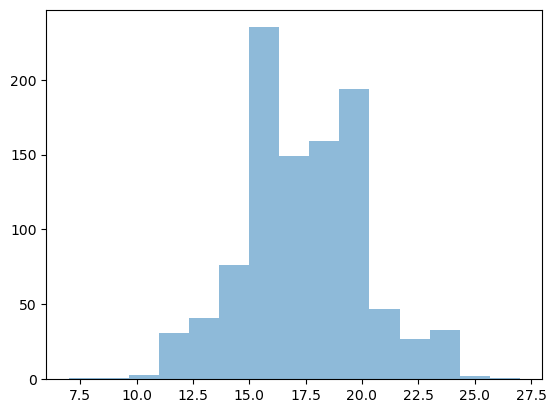

In [ ]:
# number of spikes per trial
_ = plt.hist(n_trial_spikes, bins=15, alpha=0.5, label='Spike Counts')

(array([11361., 10678.,  9843.,  9069.,  8430.,  8623.,  9121., 10174.,
        10987., 11714.]),
 array([-3.14155840e+00, -2.51324419e+00, -1.88492999e+00, -1.25661578e+00,
        -6.28301574e-01,  1.26316577e-05,  6.28326838e-01,  1.25664104e+00,
         1.88495525e+00,  2.51326946e+00,  3.14158366e+00]),
 <BarContainer object of 10 artists>)

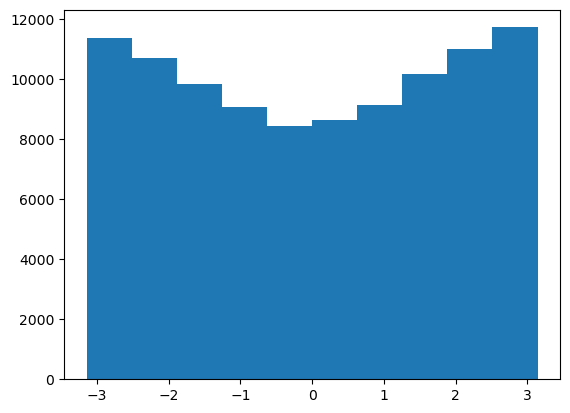

In [16]:
plt.hist(null_trial_meanphases.flatten())

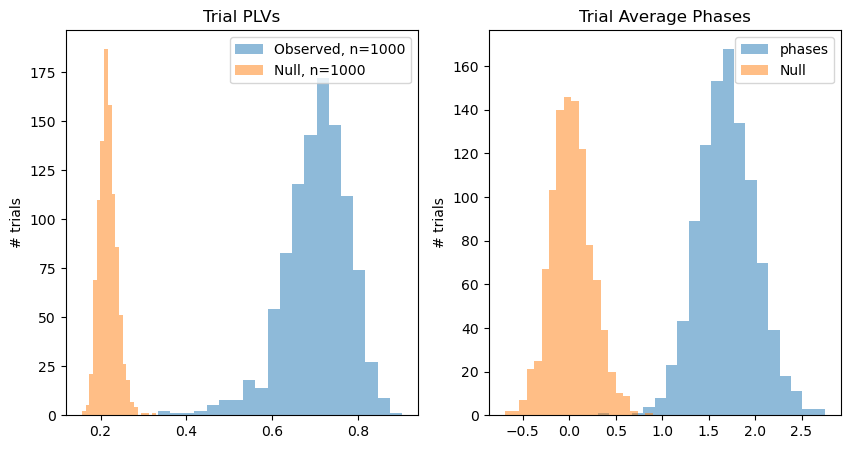

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
_ = axs[0].hist(spike_trial_plvs, bins=20, alpha=0.5, label=f'Observed, n={np.sum(~np.isnan(spike_trial_plvs))}')
_ = axs[0].hist(np.nanmean(null_trial_plvs, axis=1), bins=20, alpha=0.5, label=f'Null, n={np.sum(~np.isnan(np.nanmean(null_trial_plvs, axis=1)))}')
axs[0].legend()
axs[0].set_title('Trial PLVs')
axs[0].set_ylabel('# trials')
_ = axs[1].hist(spike_trial_phases, bins=20, alpha=0.5, label='phases')
_ = axs[1].hist(np.nanmean(null_trial_meanphases, axis=1), bins=20, alpha=0.5, label='Null')
axs[1].legend()
axs[1].set_title('Trial Average Phases')
axs[1].set_ylabel('# trials')
plt.show()

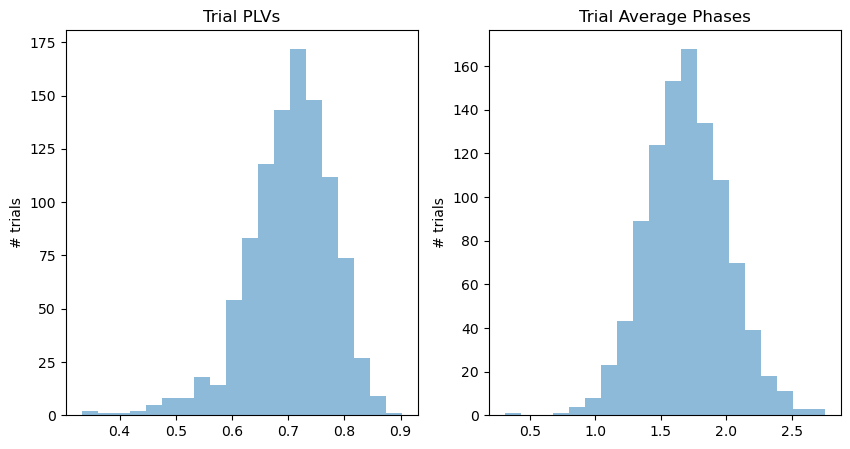

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
_ = axs[0].hist(spike_trial_plvs, bins=20, alpha=0.5, label='Observed')
axs[0].set_title('Trial PLVs')
axs[0].set_ylabel('# trials')
_ = axs[1].hist(spike_trial_phases, bins=20, alpha=0.5, label='phases')
axs[1].set_title('Trial Average Phases')
axs[1].set_ylabel('# trials')
plt.show()

In [19]:
colors = ['#6E439A','#2B1644', '#236975','#49BEA3']

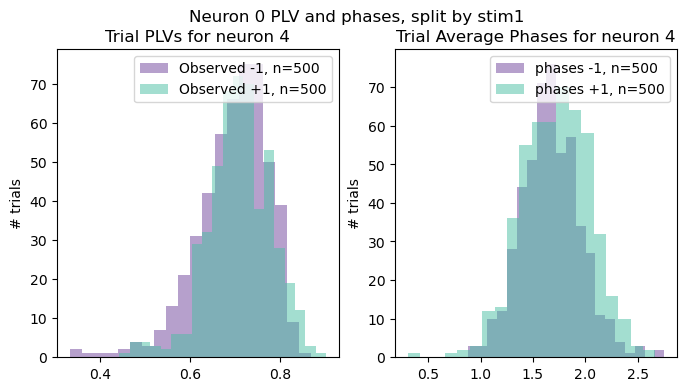

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
_ = axs[0].hist(spike_trial_plvs[:500], bins=20, alpha=0.5, label=f'Observed -1, n={np.sum(~np.isnan(spike_trial_plvs[:500]))}', color=colors[0])
_ = axs[0].hist(spike_trial_plvs[500:], bins=20, alpha=0.5, label=f'Observed +1, n={np.sum(~np.isnan(spike_trial_plvs[500:]))}', color=colors[3])
axs[0].legend()
axs[0].set_title('Trial PLVs for neuron 4')
axs[0].set_ylabel('# trials')
_ = axs[1].hist(spike_trial_phases[:500], bins=20, alpha=0.5, label=f'phases -1, n={np.sum(~np.isnan(spike_trial_phases[:500]))}', color=colors[0])
_ = axs[1].hist(spike_trial_phases[500:], bins=20, alpha=0.5, label=f'phases +1, n={np.sum(~np.isnan(spike_trial_phases[500:]))}', color=colors[3])
axs[1].legend()
axs[1].set_title('Trial Average Phases for neuron 4')
axs[1].set_ylabel('# trials')
fig.suptitle('Neuron 0 PLV and phases, split by stim1')
plt.show()

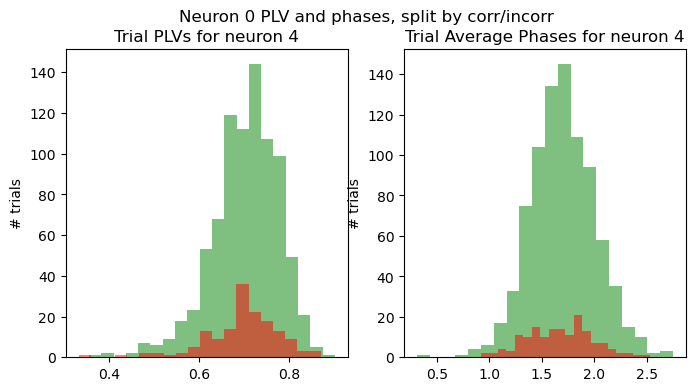

In [23]:
trial_corr = np.where(trial_perfs == 1)[0]
trial_incor = np.where(trial_perfs == 0)[0]

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
_ = axs[0].hist(spike_trial_plvs[trial_corr], bins=20, alpha=0.5, label='Observed', color='g')
_ = axs[0].hist(spike_trial_plvs[trial_incor], bins=20, alpha=0.5, label='Observed', color='r')
axs[0].set_title('Trial PLVs for neuron 4')
axs[0].set_ylabel('# trials')
_ = axs[1].hist(spike_trial_phases[trial_corr], bins=20, alpha=0.5, label='phases', color='g')
_ = axs[1].hist(spike_trial_phases[trial_incor], bins=20, alpha=0.5, label='phases', color='r')
axs[1].set_title('Trial Average Phases for neuron 4')
axs[1].set_ylabel('# trials')
fig.suptitle('Neuron 0 PLV and phases, split by corr/incorr')
plt.show()

/tmp/ipykernel_1353637/2921275378.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([spike_trial_plvs[trial_corr], spike_trial_plvs[trial_incor]], labels=['corr', 'incorr'])


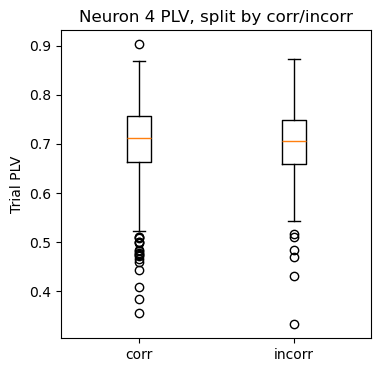

In [24]:
trial_corr = np.where(trial_perfs == 1)[0]
trial_incor = np.where(trial_perfs == 0)[0]

plt.figure(figsize=(4,4))
plt.boxplot([spike_trial_plvs[trial_corr], spike_trial_plvs[trial_incor]], labels=['corr', 'incorr'])
plt.ylabel('Trial PLV')
plt.title('Neuron 4 PLV, split by corr/incorr')
plt.show()

### repeat across neurons

In [35]:
neuron_ids = spike_df['cell_id'].unique()
phase4 = phase[:, 0, :] # (n_trials, n_times)

trial_plvs = np.zeros((len(neuron_ids), phase4.shape[0])) * np.nan
null_plvs = np.zeros((len(neuron_ids), phase4.shape[0])) * np.nan
n_trial_spikes_all = np.zeros((len(neuron_ids), phase4.shape[0])) * np.nan

for neuron_id in neuron_ids:
    print(f'Processing neuron {neuron_id}')

    phase4 = phase[:, 0, :] # (n_trials, n_times)

    spike_trial_phases, spike_trial_plvs, n_trial_spikes = get_neuron_sfc(spike_df[spike_df['cell_id'] == neuron_id], phase4, fs_spk=fs_spk, fs_lfp=fs_ds,
                                                                        times_fs=times_fs, threshold=2)
    trial_plvs[neuron_id, :] = spike_trial_plvs
    n_trial_spikes_all[neuron_id, :] = n_trial_spikes

    if np.sum(~np.isnan(spike_trial_plvs)) > 0:
        null_trial_plvs, null_trial_meanphases = get_null_sfc(n_trial_spikes, phase4, times_fs, n_shuffles=100)
        null_plvs[neuron_id, :] = np.nanmean(null_trial_plvs, axis=1) # mean across shuffles
    else:
        # null_plvs remain as NaN
        print('Not enough spikes to compute SFC')

Processing neuron 0
Not enough spikes to compute SFC
Processing neuron 1
Processing neuron 2
Not enough spikes to compute SFC
Processing neuron 3


/tmp/ipykernel_1353637/4261056238.py:20: RuntimeWarning: Mean of empty slice
  null_plvs[neuron_id, :] = np.nanmean(null_trial_plvs, axis=1) # mean across shuffles


Processing neuron 4
Processing neuron 5
Processing neuron 6
Not enough spikes to compute SFC
Processing neuron 7
Not enough spikes to compute SFC
Processing neuron 8
Not enough spikes to compute SFC
Processing neuron 9
Processing neuron 10
Processing neuron 11
Not enough spikes to compute SFC
Processing neuron 12
Not enough spikes to compute SFC
Processing neuron 13
Processing neuron 14
Not enough spikes to compute SFC
Processing neuron 15
Not enough spikes to compute SFC
Processing neuron 16
Processing neuron 17
Processing neuron 18
Processing neuron 19
Processing neuron 20
Processing neuron 21
Processing neuron 22
Processing neuron 23
Processing neuron 24
Processing neuron 25
Not enough spikes to compute SFC
Processing neuron 26
Processing neuron 27
Processing neuron 28
Processing neuron 29
Processing neuron 30
Processing neuron 31
Processing neuron 32
Not enough spikes to compute SFC
Processing neuron 33
Processing neuron 34
Processing neuron 35
Not enough spikes to compute SFC
Proc

In [70]:
# save as pk into data folders
import pickle as pk

file_name = os.path.join(model_dir, f'SFC_delay{delay}_trialPLVs.pkl')
with open(file_name, 'wb') as f:
    pk.dump(trial_plvs, f)
    pk.dump(null_plvs, f)
    pk.dump(n_trial_spikes_all, f)

In [36]:
print(trial_plvs.shape, null_plvs.shape, n_trial_spikes_all.shape)

(200, 1000) (200, 1000) (200, 1000)


In [38]:
# how many neurons don't have enough spikes
print(f'Number of neurons: {len(neuron_ids)}')
print(f'Number of neurons with SFC computed: {np.sum(~np.isnan(np.nanmean(trial_plvs, axis=1)))}')

Number of neurons: 200
Number of neurons with SFC computed: 130


/tmp/ipykernel_1353637/2723640611.py:3: RuntimeWarning: Mean of empty slice
  print(f'Number of neurons with SFC computed: {np.sum(~np.isnan(np.nanmean(trial_plvs, axis=1)))}')


/tmp/ipykernel_1353637/3484091149.py:3: RuntimeWarning: Mean of empty slice
  plt.scatter(np.nanmean(trial_plvs, axis=1), np.nanmean(null_plvs, axis=1))


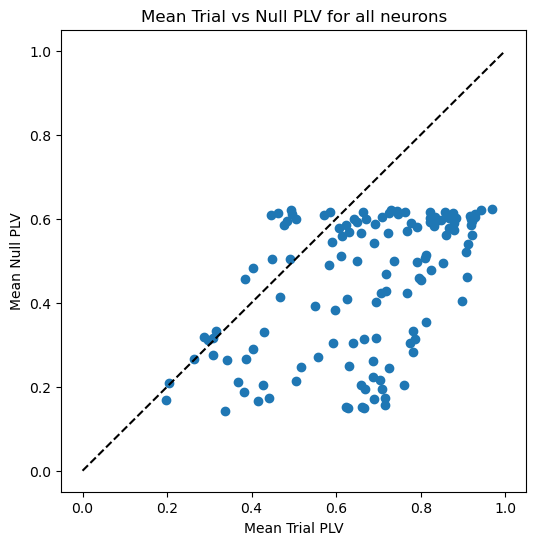

In [37]:
# plot trial vs null PLVs for all neurons
plt.figure(figsize=(6,6))
plt.scatter(np.nanmean(trial_plvs, axis=1), np.nanmean(null_plvs, axis=1))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Mean Trial PLV')
plt.ylabel('Mean Null PLV')
plt.title('Mean Trial vs Null PLV for all neurons')
plt.show()

In [44]:
neuron_df = spike_df[spike_df['trial_id'] == 0]
neuron_labels = neuron_df['cell_type']

exc_inds = np.where(neuron_labels == 'exc')[0]
inh_inds = np.where(neuron_labels == 'inh')[0]

exc_bool = neuron_labels == 'exc'

/tmp/ipykernel_1353637/2189691407.py:12: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = mannwhitneyu(trial_plvs[i_neuron, trial_corr], trial_plvs[i_neuron, trial_incor], alternative='two-sided', nan_policy='omit')
/tmp/ipykernel_1353637/2189691407.py:17: RuntimeWarning: Mean of empty slice
  plt.scatter(np.nanmean(trial_plvs[i_neuron, trial_corr]), np.nanmean(trial_plvs[i_neuron, trial_incor]), c=c, alpha=0.5)


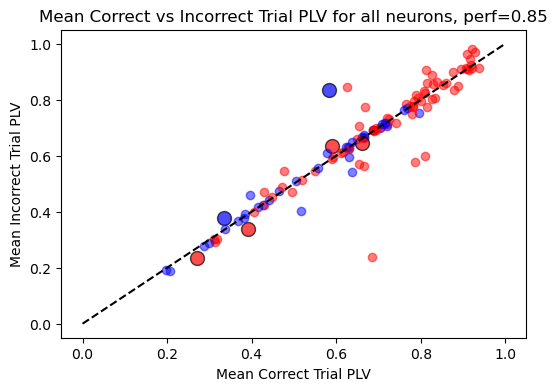

In [62]:
# plot correct vs incorrect trial mean PLV for all neurons
from scipy.stats import mannwhitneyu

trial_corr = np.where(trial_perfs == 1)[0]
trial_incor = np.where(trial_perfs == 0)[0]

sig_neurons = []

plt.figure(figsize=(6,4))
for i_neuron in neuron_ids:
    c = ['r' if exc_bool[i_neuron] else 'b'][0]
    stat, p = mannwhitneyu(trial_plvs[i_neuron, trial_corr], trial_plvs[i_neuron, trial_incor], alternative='two-sided', nan_policy='omit')
    if p < 0.05:
        plt.scatter(np.nanmean(trial_plvs[i_neuron, trial_corr]), np.nanmean(trial_plvs[i_neuron, trial_incor]), c=c, edgecolor='k', s=100, alpha=0.7)
        sig_neurons.append(i_neuron)
    else:
        plt.scatter(np.nanmean(trial_plvs[i_neuron, trial_corr]), np.nanmean(trial_plvs[i_neuron, trial_incor]), c=c, alpha=0.5)
# plt.scatter(np.nanmean(trial_plvs[:, trial_corr], axis=1), np.nanmean(trial_plvs[:, trial_incor], axis=1),c=exc_bool, cmap='bwr', alpha=0.7)
# plt.colorbar(label='Excitatory (1) / Inhibitory (0)')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Mean Correct Trial PLV')
plt.ylabel('Mean Incorrect Trial PLV')
plt.title(f'Mean Correct vs Incorrect Trial PLV for all neurons, perf={np.mean(trial_perfs):.2f}')
plt.show()

In [63]:
(print(len(sig_neurons), sig_neurons))

6 [40, 60, 77, 94, 129, 154]


In [61]:
trial_plvs[sig_neurons,:].shape

(6, 1000)

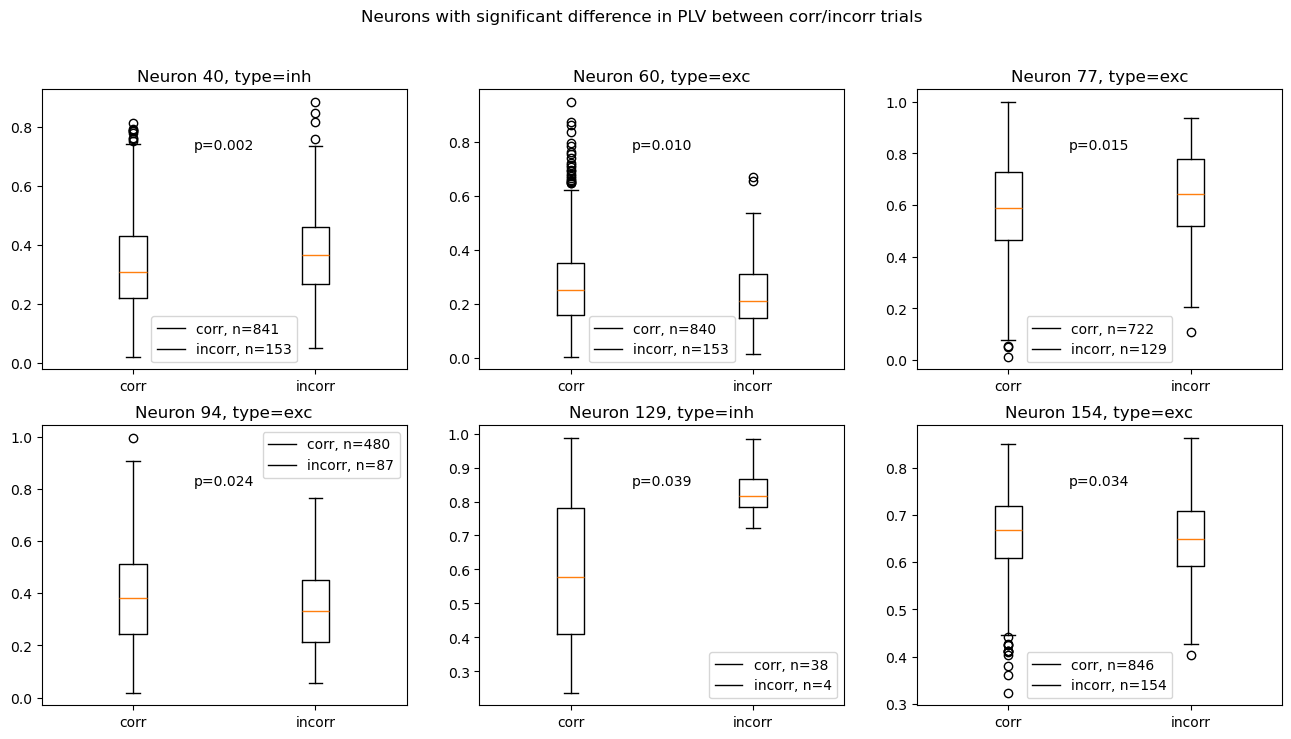

In [68]:
fig, axs = plt.subplots(2,3, figsize=(16,8))
axs = axs.flatten()
for i, neuron_id in enumerate(sig_neurons):
    corr_plvs = trial_plvs[neuron_id, trial_corr]
    incor_plvs = trial_plvs[neuron_id, trial_incor]
    axs[i].boxplot([corr_plvs[~np.isnan(corr_plvs)], incor_plvs[~np.isnan(incor_plvs)]])
    axs[i].set_title(f'Neuron {neuron_id}, type={neuron_labels[neuron_id]}')
    axs[i].set_xticklabels(['corr', 'incorr'])
    axs[i].legend([f'corr, n={len(corr_plvs[~np.isnan(corr_plvs)])}', f'incorr, n={len(incor_plvs[~np.isnan(incor_plvs)])}'])
    stat, p = mannwhitneyu(corr_plvs, incor_plvs, alternative='two-sided', nan_policy='omit')
    axs[i].text(0.5, 0.8, f'p={p:.3f}', ha='center', va='center', transform=axs[i].transAxes)
plt.suptitle('Neurons with significant difference in PLV between corr/incorr trials')
plt.show()

/tmp/ipykernel_1353637/240843609.py:7: RuntimeWarning: Mean of empty slice
  plt.scatter(np.nanmean(null_plvs[:, trial_corr], axis=1), np.nanmean(null_plvs[:, trial_incor], axis=1),c=exc_bool, cmap='bwr', alpha=0.7)


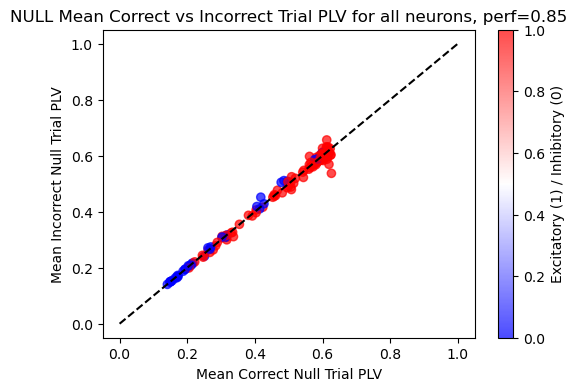

In [51]:
# plot correct vs incorrect trial mean PLV for all neurons, null condition

trial_corr = np.where(trial_perfs == 1)[0]
trial_incor = np.where(trial_perfs == 0)[0]

plt.figure(figsize=(6,4))
plt.scatter(np.nanmean(null_plvs[:, trial_corr], axis=1), np.nanmean(null_plvs[:, trial_incor], axis=1),c=exc_bool, cmap='bwr', alpha=0.7)
plt.colorbar(label='Excitatory (1) / Inhibitory (0)')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Mean Correct Null Trial PLV')
plt.ylabel('Mean Incorrect Null Trial PLV')
plt.title(f'NULL Mean Correct vs Incorrect Trial PLV for all neurons, perf={np.mean(trial_perfs):.2f}')
plt.show()

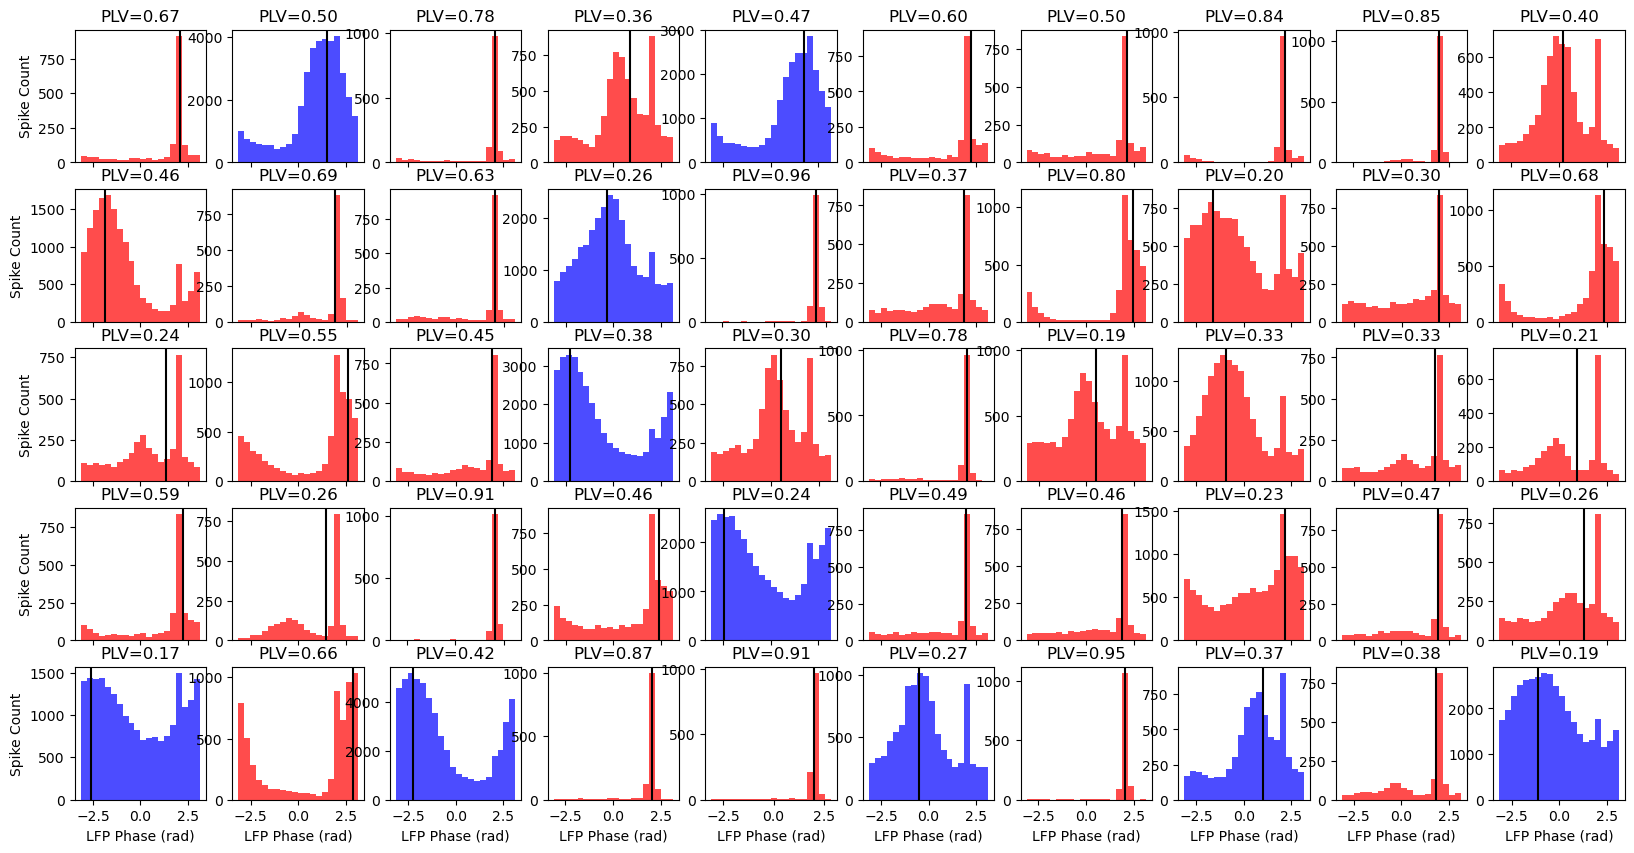

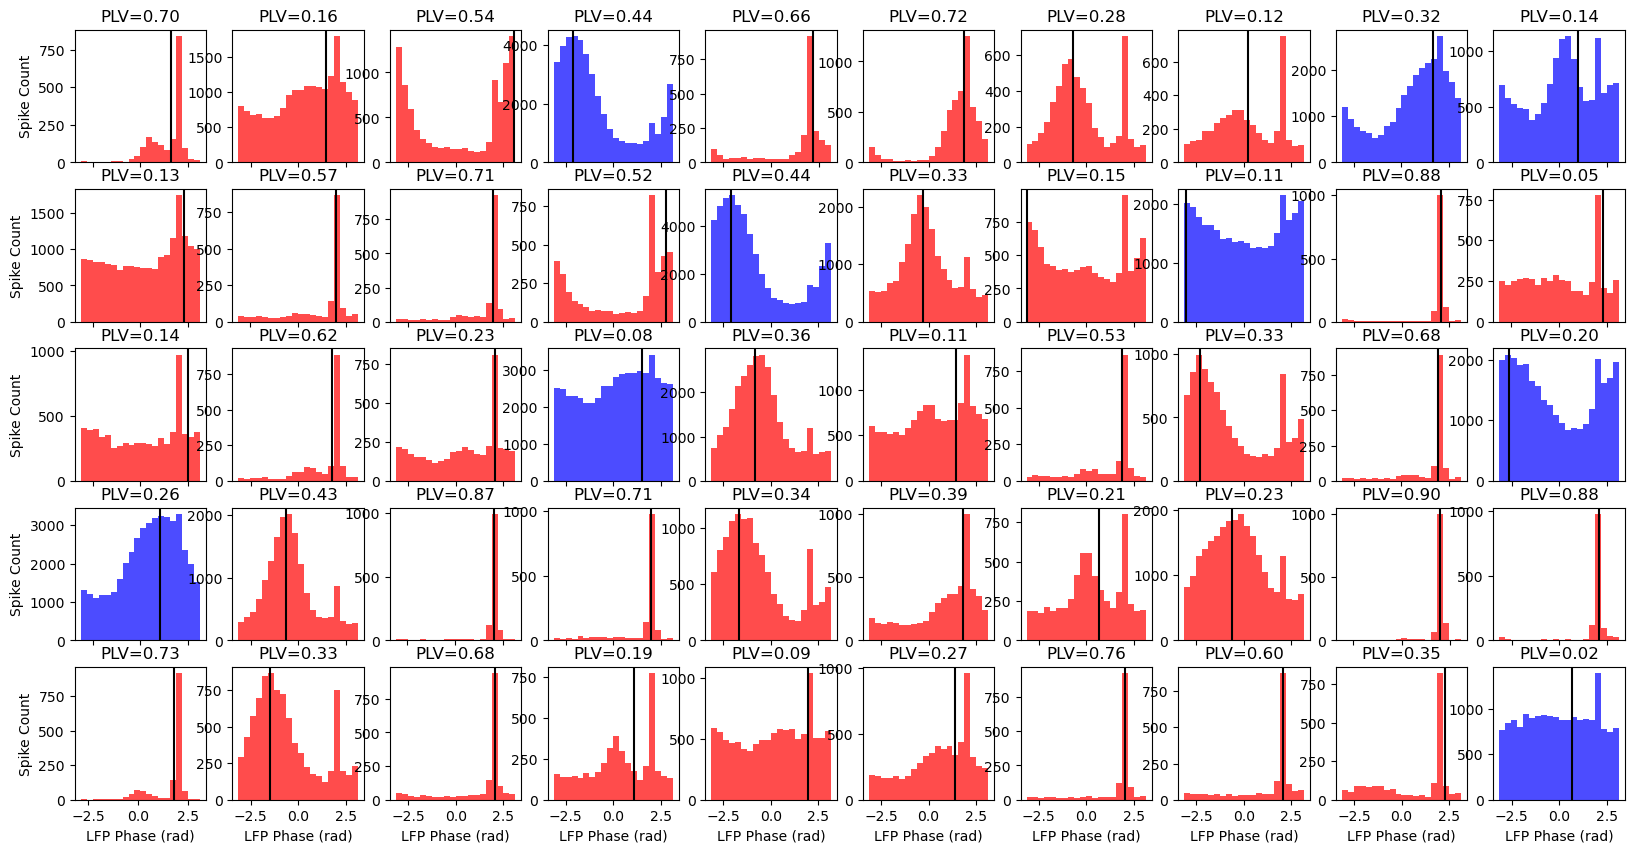

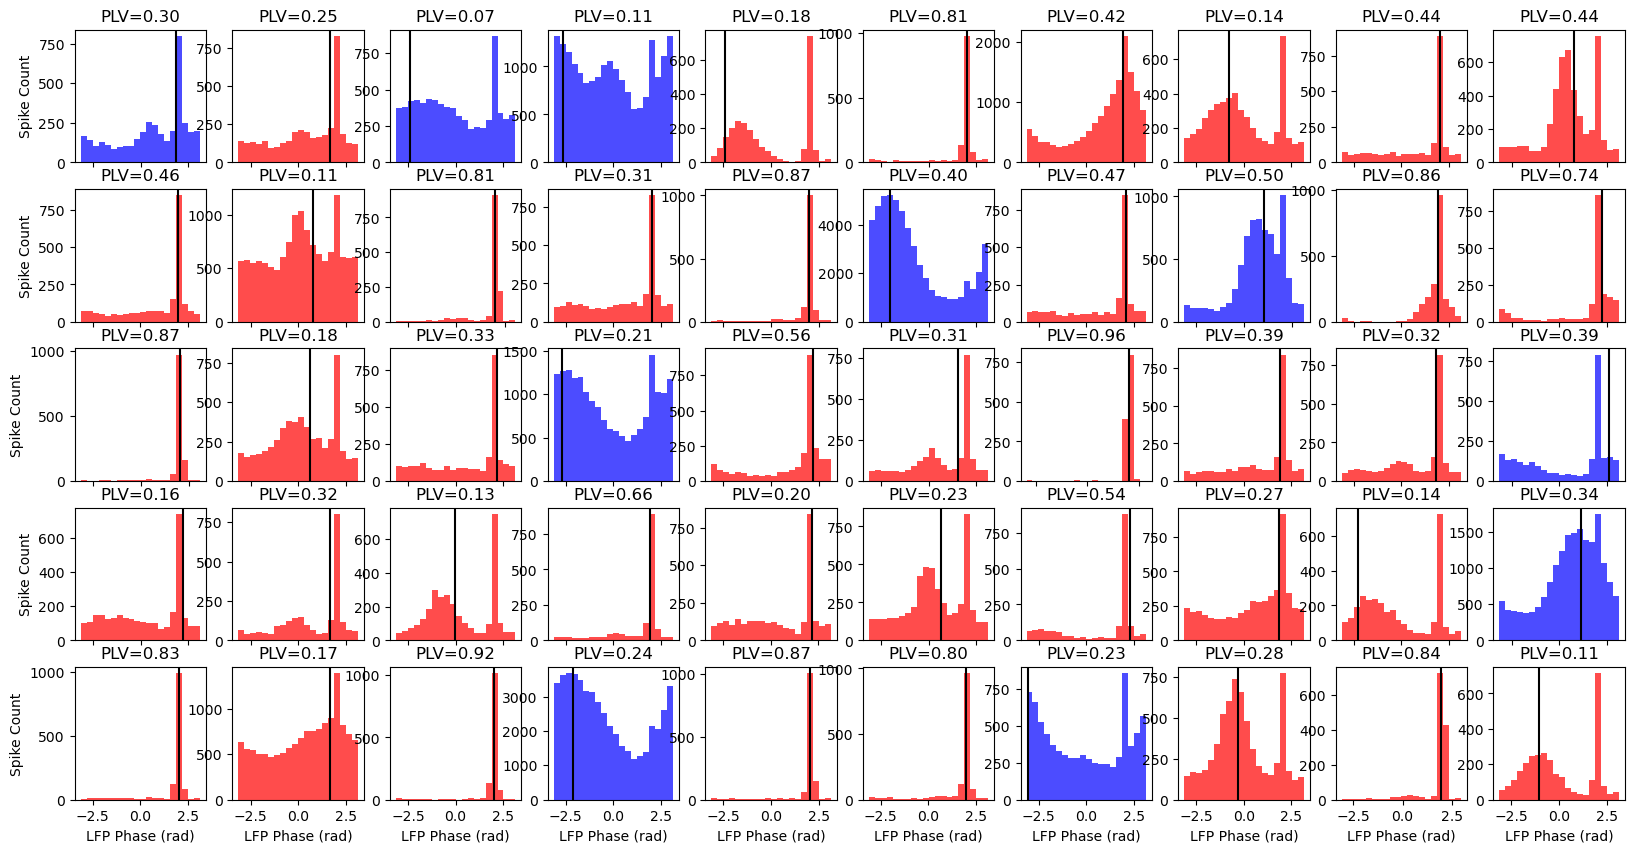

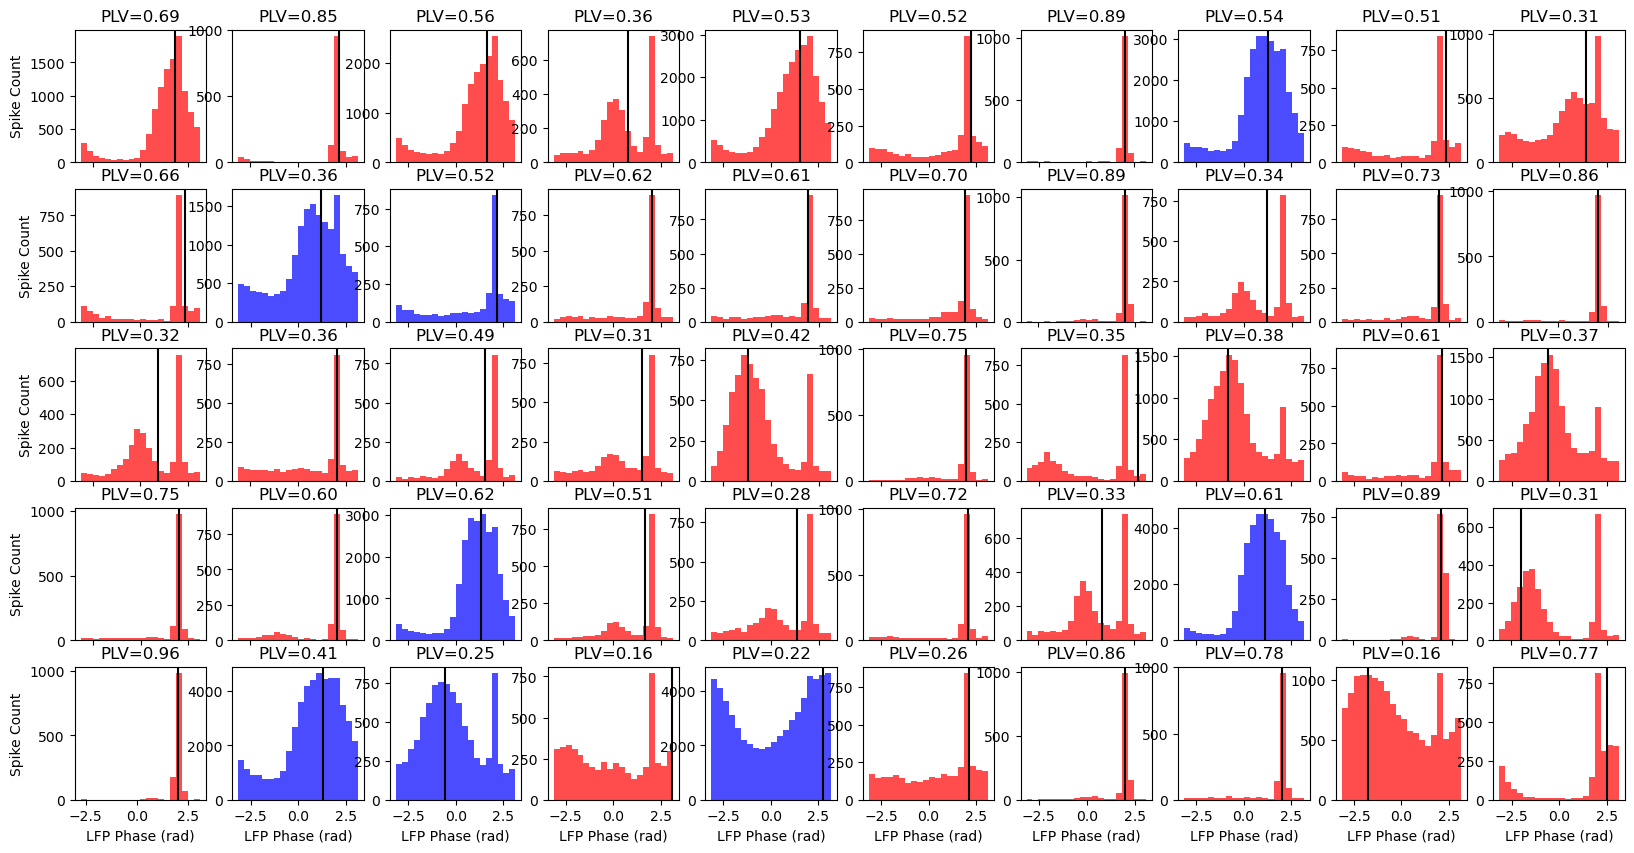

In [ ]:
# iterate thru all neurons and plot
neuron_ids = spike_df['cell_id'].unique()

plvs = []
for neuron_id in neuron_ids:
    if neuron_id % 50 == 0:
        fig, axs = plt.subplots(5, 10, figsize=(20, 10))
        axs = axs.flatten()
    
    ax = axs[neuron_id % 50]
    
    neuron_df = spike_df[spike_df['cell_id'] == neuron_id]
    neuron_type = neuron_df['cell_type'].values[0]
    if neuron_type == 'exc':
        c = 'r'
    else:
        c = 'b'
    mean_phase, plv, spike_phases = get_neuron_sfc(neuron_df, phase4, fs_spk=fs_spk, fs_lfp=fs_ds)
    plvs.append(plv)
    
    ax.hist(spike_phases, bins=20, color=c, alpha=0.7)
    ax.axvline(mean_phase, color='k', label='Mean Phase')
    ax.set_title(f'PLV={plv:.2f}')
    if neuron_id % 50 >= 40:
        ax.set_xlabel('LFP Phase (rad)')
    else:
        ax.set_xticklabels('')
    if (neuron_id % 50) % 10 == 0:
        ax.set_ylabel('Spike Count')
    # else:
    #     ax.set_yticklabels('')
    

In [ ]:
colors = ['#6E439A','#2B1644', '#236975','#49BEA3']

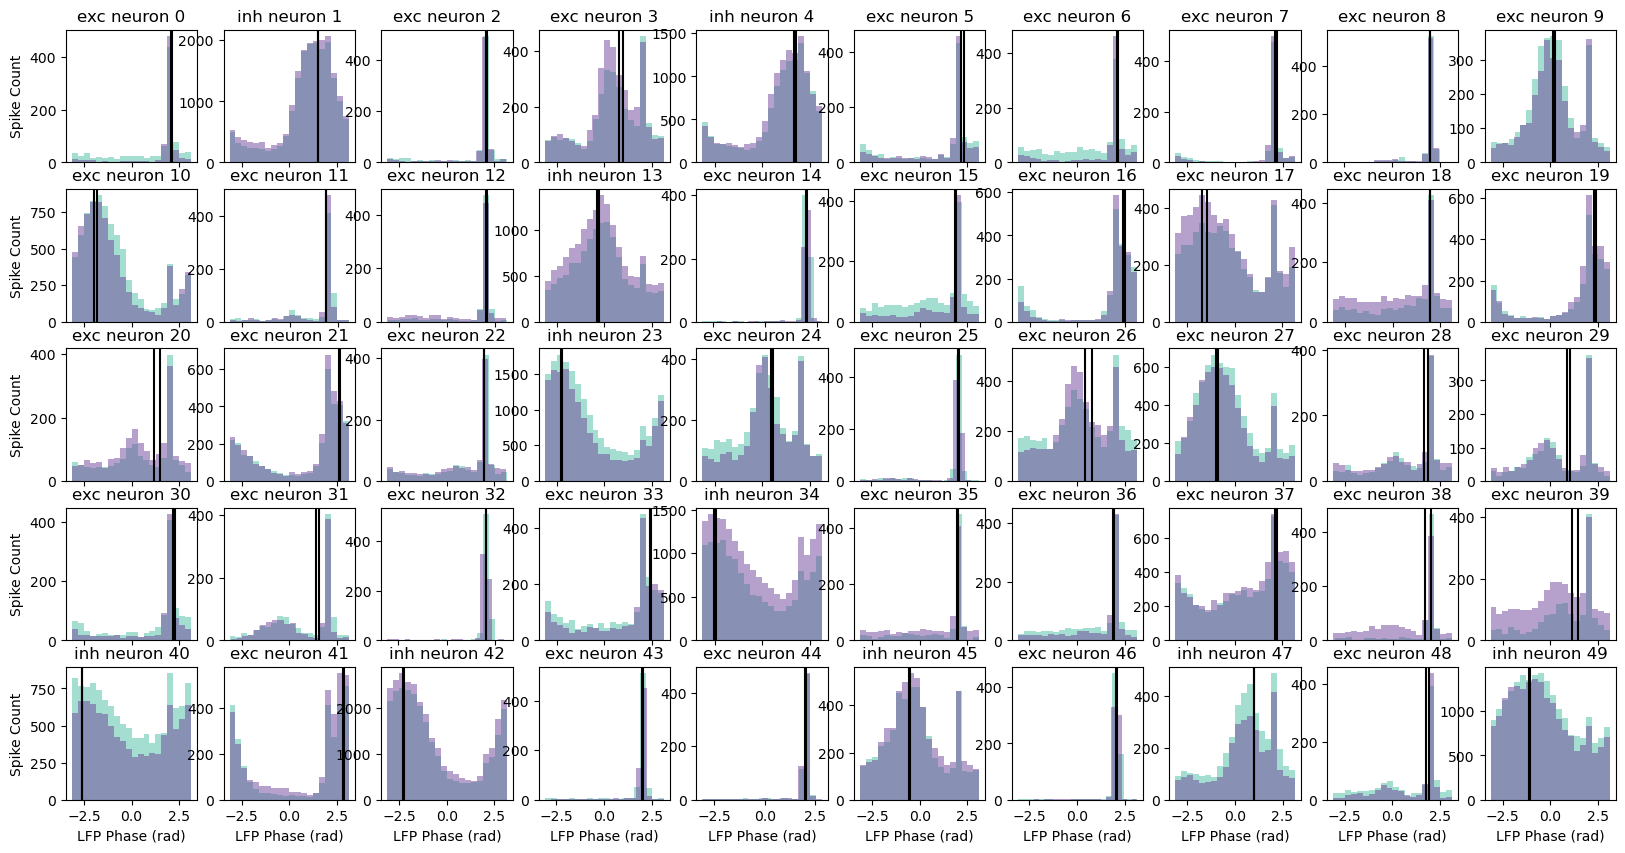

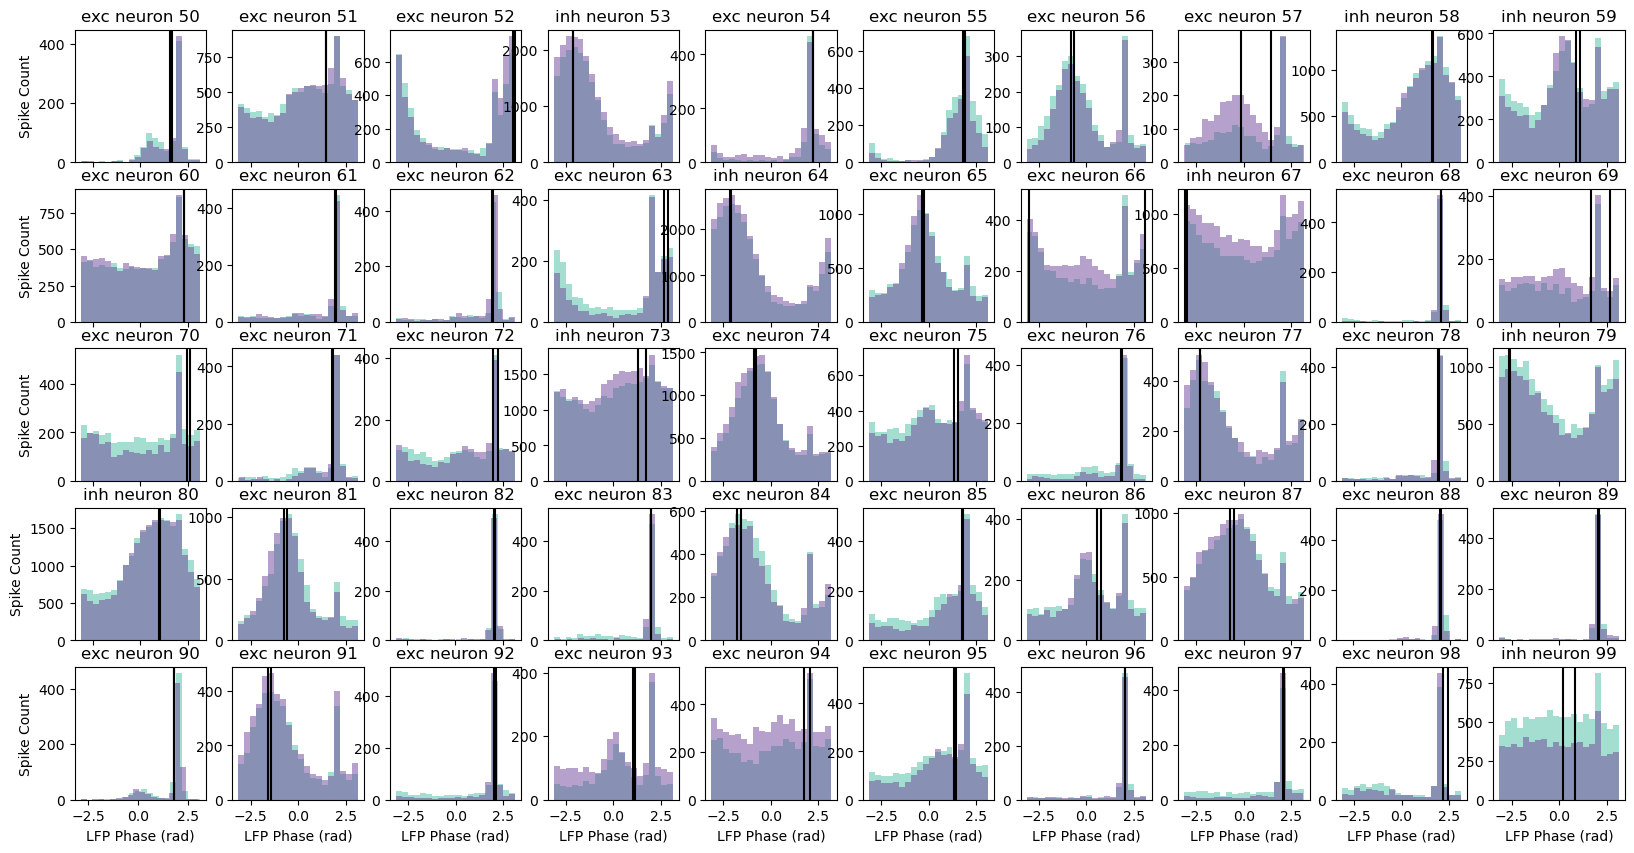

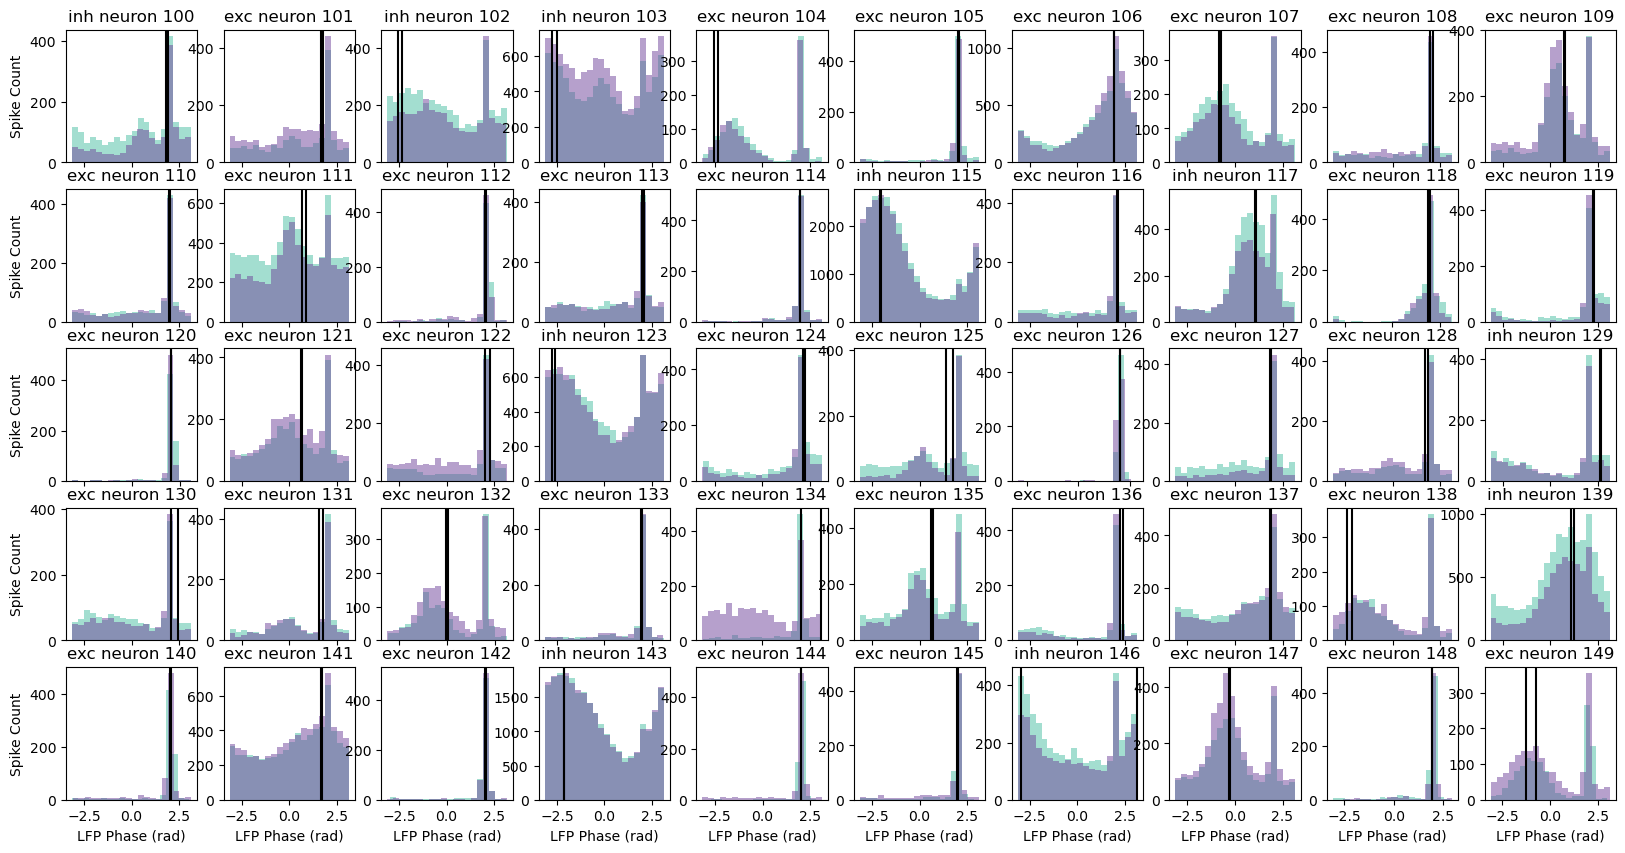

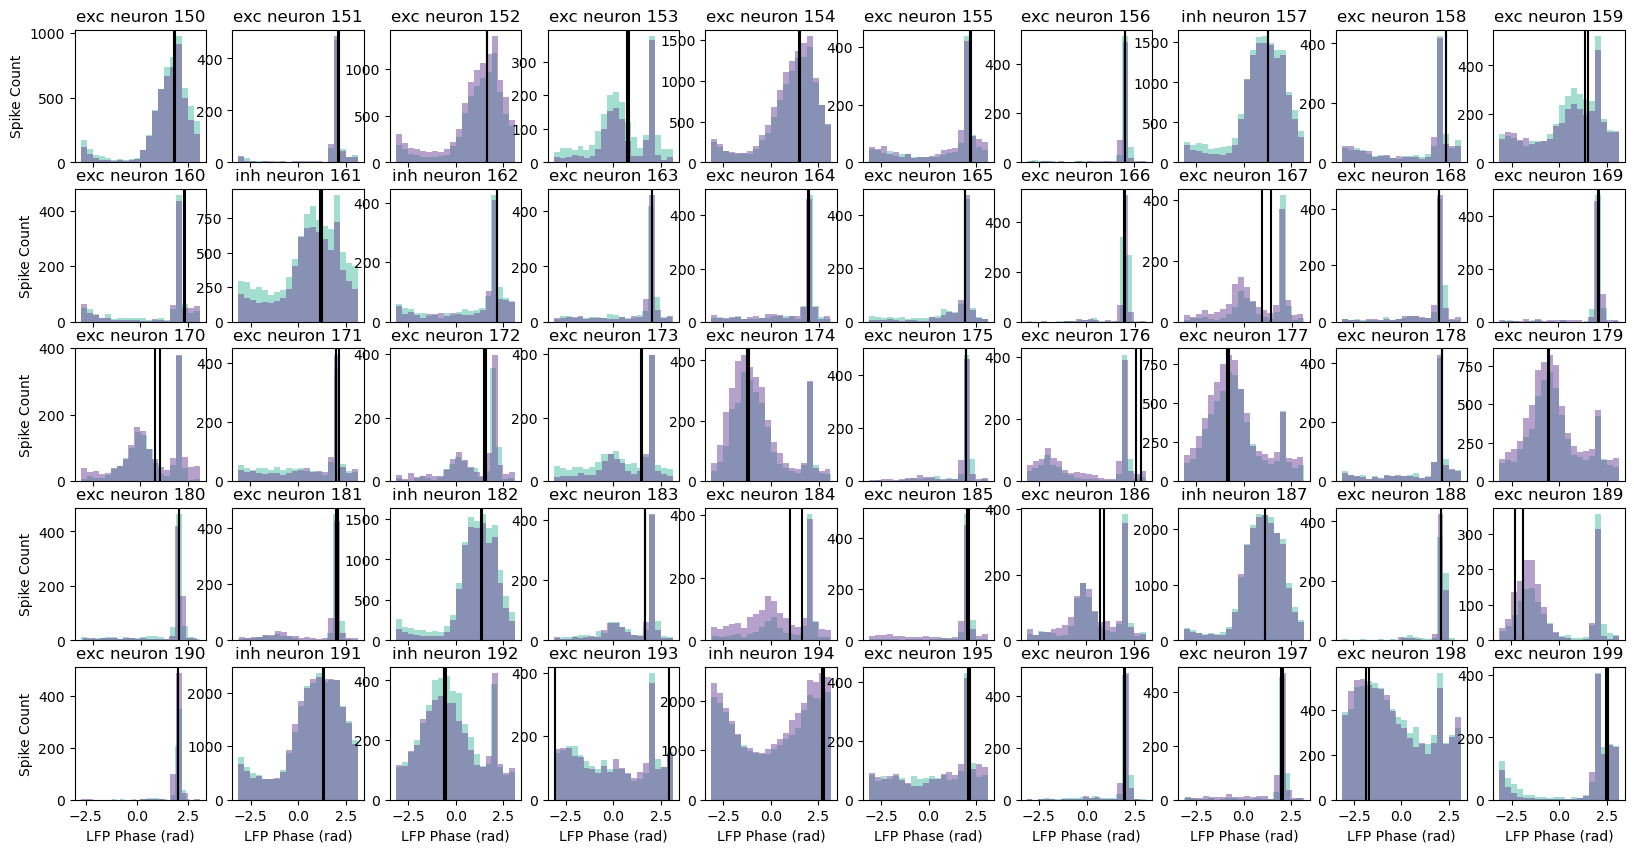

In [ ]:
# iterate thru all neurons and plot
neuron_ids = spike_df['cell_id'].unique()

trial_pos = np.where(trial_labels[:,0] == 1)[0]
trial_neg = np.where(trial_labels[:,0] == -1)[0]

for neuron_id in neuron_ids:
    if neuron_id % 50 == 0:
        fig, axs = plt.subplots(5, 10, figsize=(20, 10))
        axs = axs.flatten()
    
    ax = axs[neuron_id % 50]
    
    neuron_df = spike_df[spike_df['cell_id'] == neuron_id]
    neuron_type = neuron_df['cell_type'].values[0]
    if neuron_type == 'exc':
        c = 'r'
    else:
        c = 'b'
    mean_phase_pos, _, spike_phases_pos = get_neuron_sfc(neuron_df[neuron_df['trial_id'].isin(trial_pos)], phase4, fs_spk=fs_spk, fs_lfp=fs_ds)
    mean_phase_neg, _, spike_phases_neg = get_neuron_sfc(neuron_df[neuron_df['trial_id'].isin(trial_neg)], phase4, fs_spk=fs_spk, fs_lfp=fs_ds)
    
    ax.hist(spike_phases_pos, bins=20, color=colors[3], alpha=0.5)
    ax.hist(spike_phases_neg, bins=20, color=colors[0], alpha=0.5)
    ax.axvline(mean_phase_pos, color='k', label='Mean Phase')
    ax.axvline(mean_phase_neg, color='k', label='Mean Phase')
    ax.set_title(f'{neuron_type} neuron {neuron_id}')
    if neuron_id % 50 >= 40:
        ax.set_xlabel('LFP Phase (rad)')
    else:
        ax.set_xticklabels('')
    if (neuron_id % 50) % 10 == 0:
        ax.set_ylabel('Spike Count')
    # else:
    #     ax.set_yticklabels('')
    

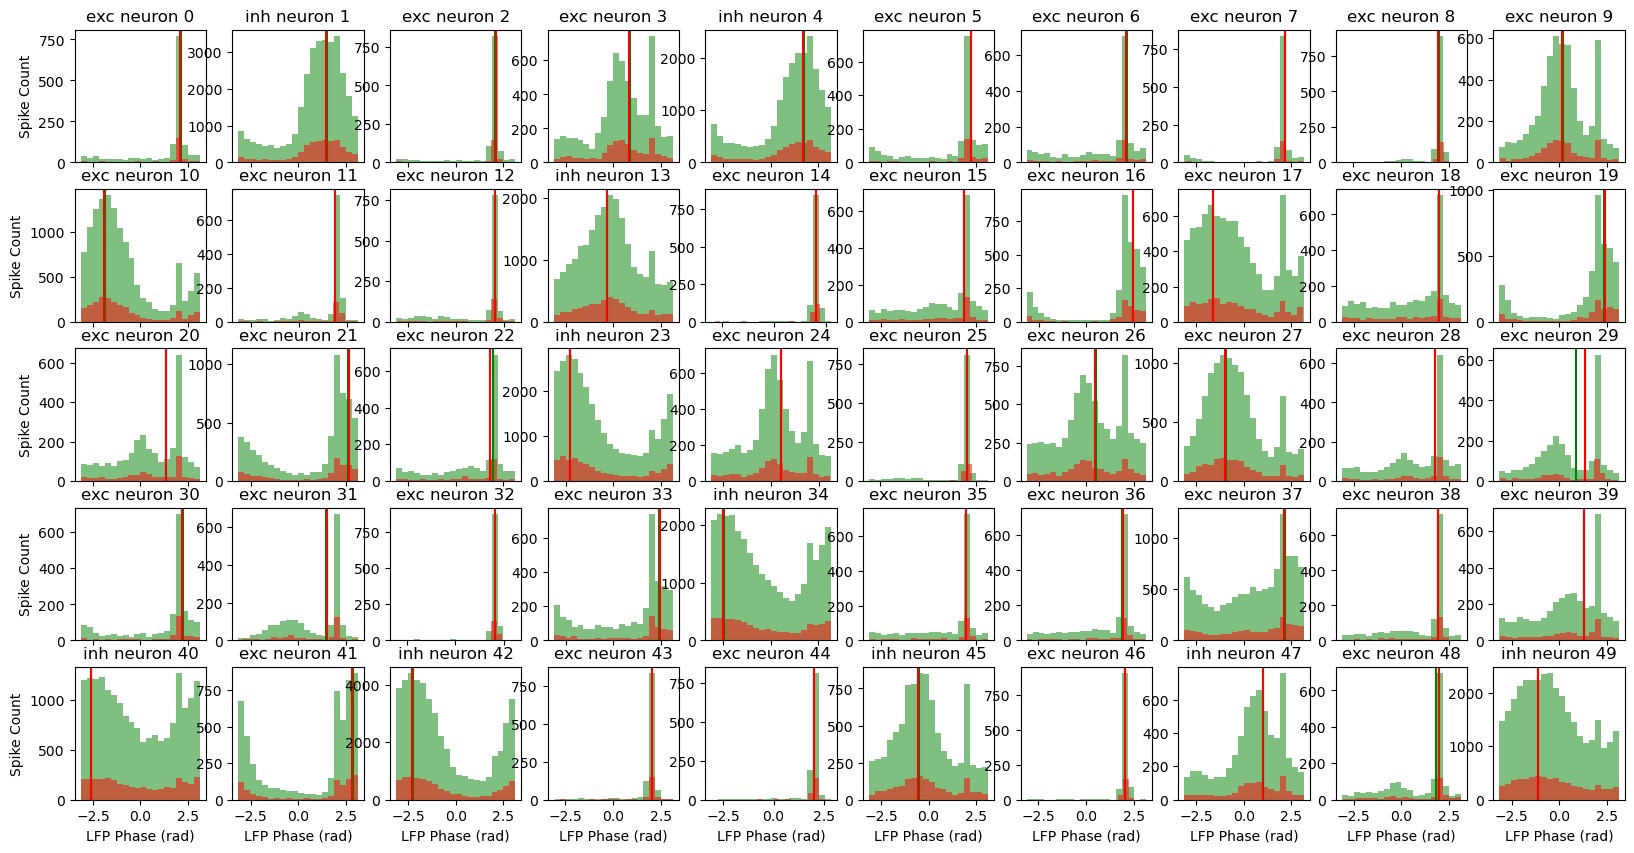

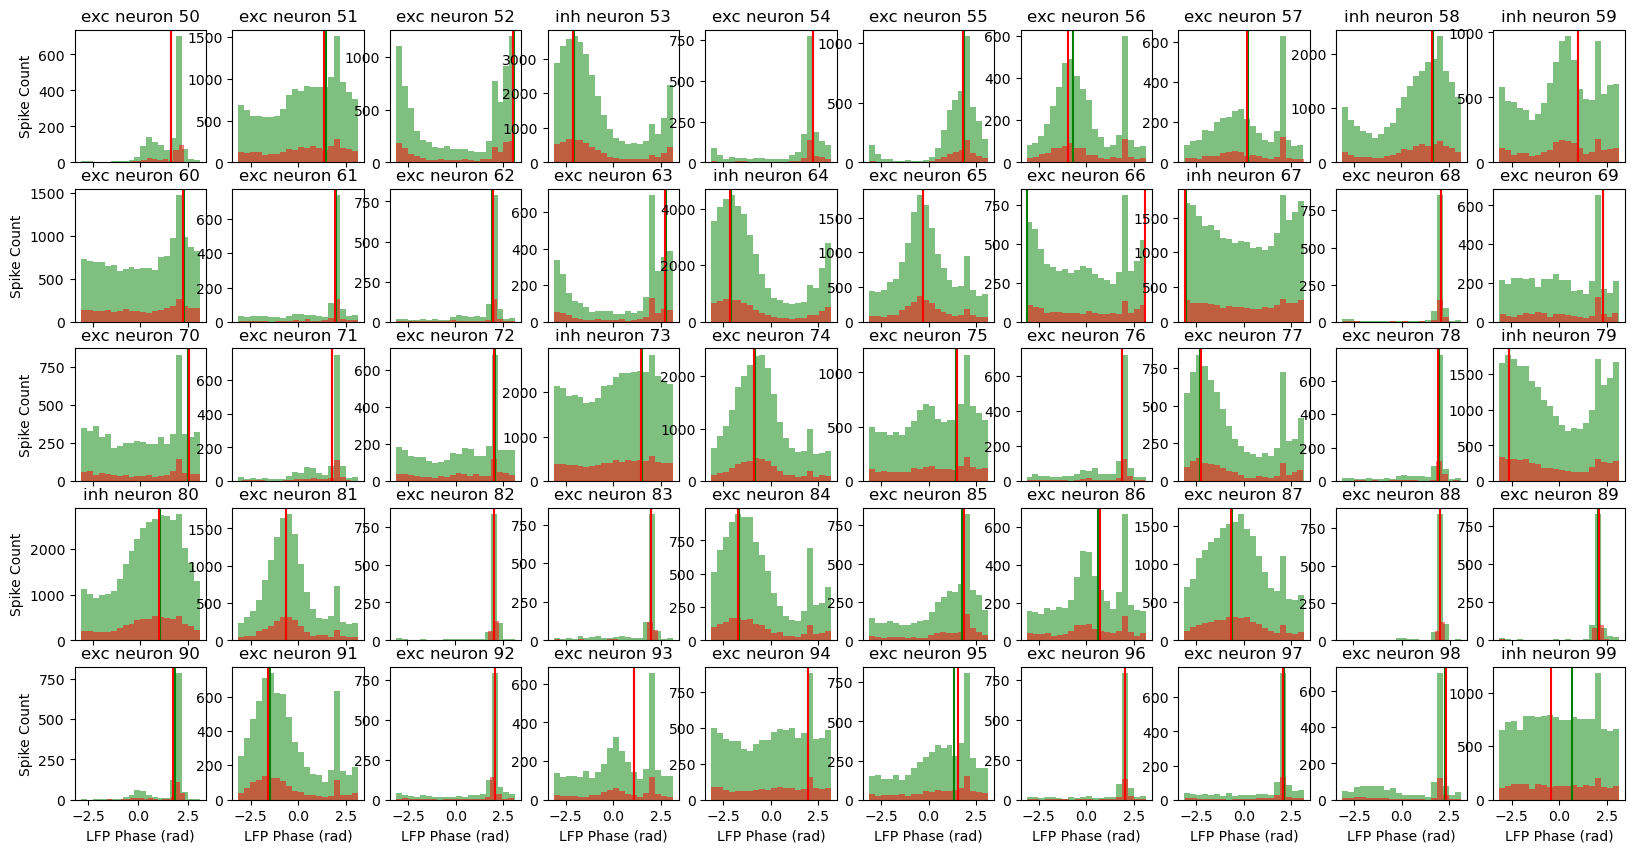

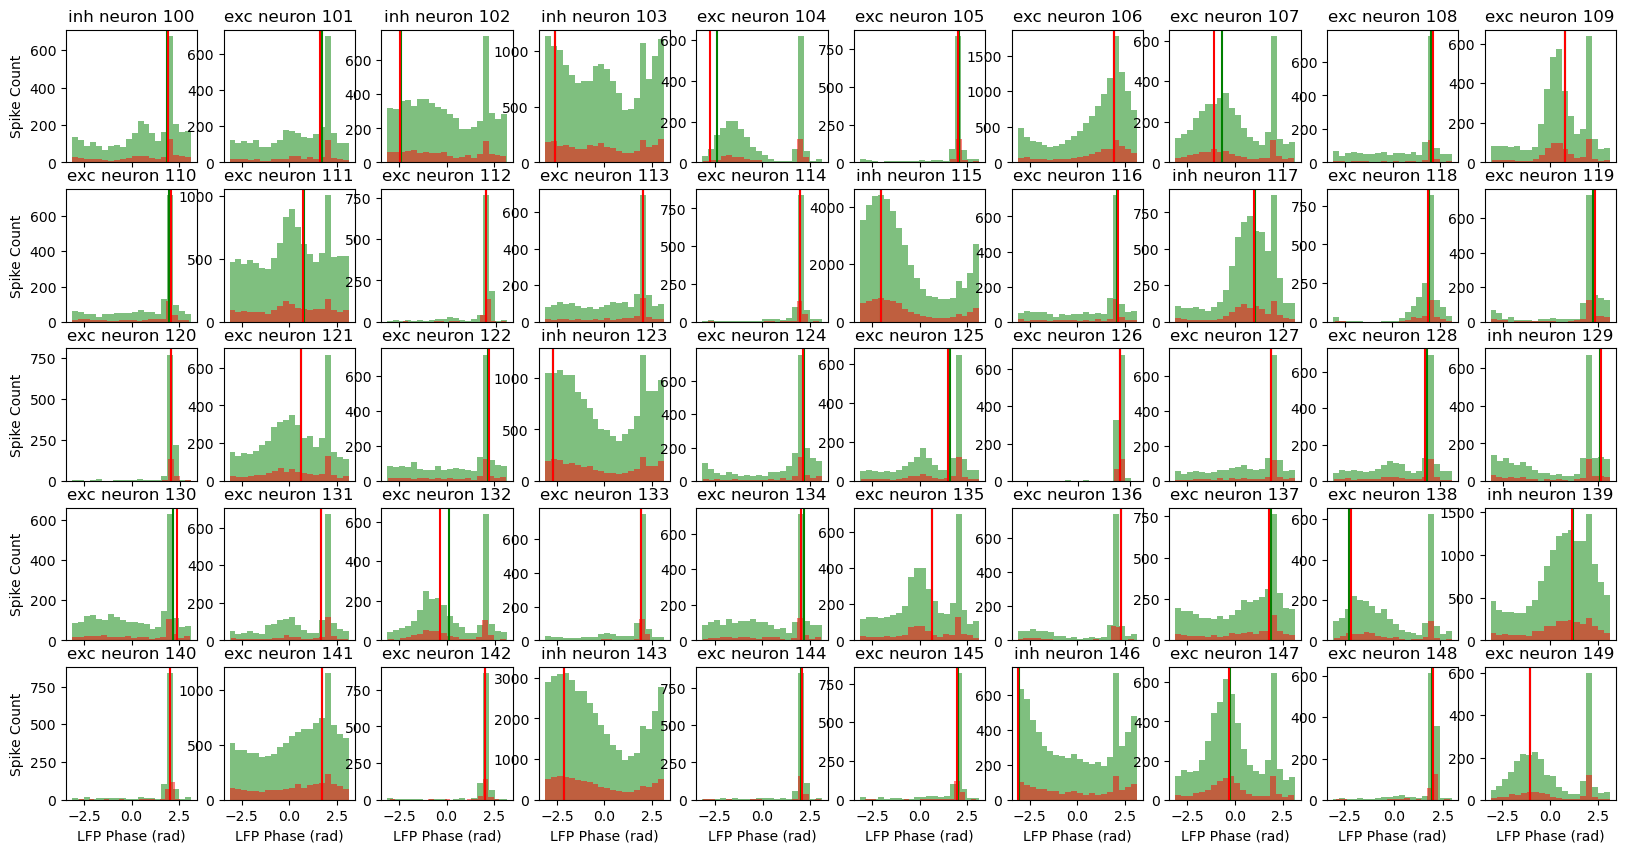

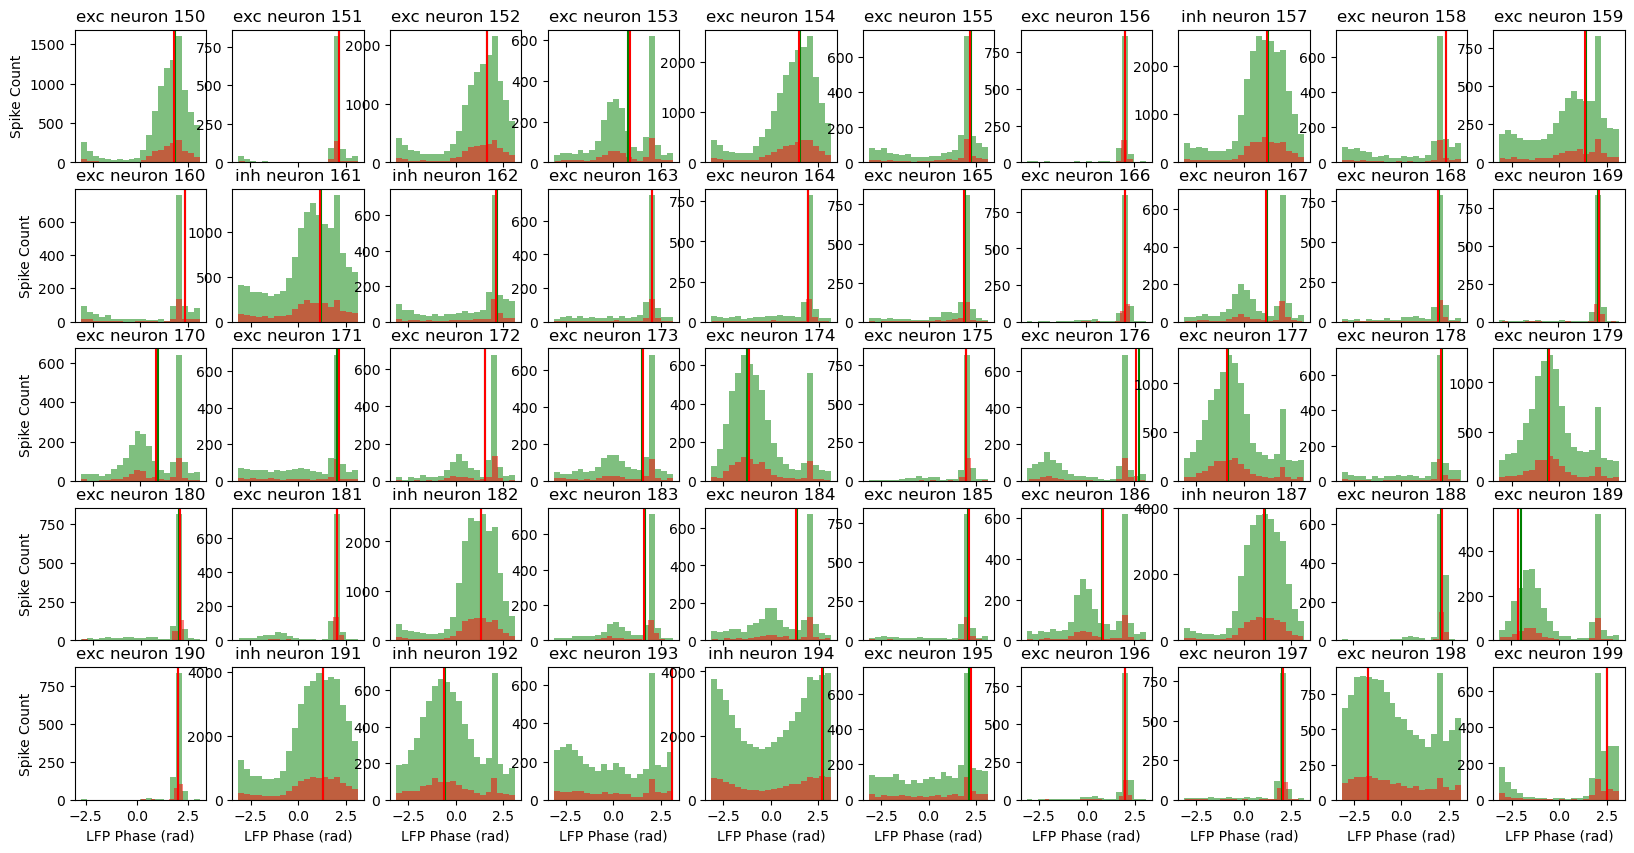

In [ ]:
# iterate thru all neurons and plot
neuron_ids = spike_df['cell_id'].unique()

trial_corr = np.where(trial_perfs == 1)[0]
trial_incor = np.where(trial_perfs == 0)[0]

for neuron_id in neuron_ids:
    if neuron_id % 50 == 0:
        fig, axs = plt.subplots(5, 10, figsize=(20, 10))
        axs = axs.flatten()
    
    ax = axs[neuron_id % 50]
    
    neuron_df = spike_df[spike_df['cell_id'] == neuron_id]
    neuron_type = neuron_df['cell_type'].values[0]
    if neuron_type == 'exc':
        c = 'r'
    else:
        c = 'b'
    mean_phase_corr, _, spike_phases_corr = get_neuron_sfc(neuron_df[neuron_df['trial_id'].isin(trial_corr)], phase4, fs_spk=fs_spk, fs_lfp=fs_ds)
    mean_phase_incorr, _, spike_phases_incorr = get_neuron_sfc(neuron_df[neuron_df['trial_id'].isin(trial_incor)], phase4, fs_spk=fs_spk, fs_lfp=fs_ds)
    
    ax.hist(spike_phases_corr, bins=20, color='g', alpha=0.5)
    ax.hist(spike_phases_incorr, bins=20, color='r', alpha=0.5)
    ax.axvline(mean_phase_corr, color='g', label='Mean Phase')
    ax.axvline(mean_phase_incorr, color='r', label='Mean Phase')
    ax.set_title(f'{neuron_type} neuron {neuron_id}')
    if neuron_id % 50 >= 40:
        ax.set_xlabel('LFP Phase (rad)')
    else:
        ax.set_xticklabels('')
    if (neuron_id % 50) % 10 == 0:
        ax.set_ylabel('Spike Count')
    # else:
    #     ax.set_yticklabels('')
    

## generate data across models

In [ ]:
importlib.reload(sfc)

n_shuffles = 100

for model_name in theta4_dirs:
    model_dir = os.path.join(all_models_dir, model_name)
    file_name = os.path.join(model_dir, f'SFC_delay{delay}_trialPLVs.pkl')
    
    if os.path.exists(file_name):
        print(f'File {file_name} exists, moving to next model...')
        continue
    
    # neural data
    lfp_data, spike_df, _ = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                                    load_LFP=True, load_spikes=True, load_rates=False,
                                                    all_models_dir=all_models_dir)

    # behavioral data
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)

    # timing data
    _,_, fs_dict = ld.load_timing_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    times_fs, times_real, fs_dict = ld.get_times_dict('ds', condn_phrase, condn_num, model_name=model_name, all_models_dir=all_models_dir)
    
    # average LFP data over neurons, and compute power and phase    
    fs_ds = int(fs_dict['ds'])
    fs_rate = int(fs_dict['rate'])
    fs_spk = int(fs_dict['spk'])

    power, freqs, phase = lu.compute_lfp_power(np.mean(lfp_data, axis=1).T, fs=fs_ds) # average across neurons. power is (n_trials, n_freqs, n_times)
    bandpower, band_sem = lu.calc_band_power(power, freqs, [4], baseline_times=[int(10/fs_rate*fs_ds), int(50/fs_rate*fs_ds)])
    
    # compute SFC for all neurons
    neuron_ids = spike_df['cell_id'].unique()
    phase4 = phase[:, 0, :] # (n_trials, n_times)

    trial_plvs = np.zeros((len(neuron_ids), phase4.shape[0])) * np.nan
    null_plvs = np.zeros((len(neuron_ids), phase4.shape[0], n_shuffles)) * np.nan
    n_trial_spikes_all = np.zeros((len(neuron_ids), phase4.shape[0])) * np.nan

    for neuron_id in neuron_ids:
        phase4 = phase[:, 0, :] # (n_trials, n_times) — 4Hz only

        spike_trial_phases, spike_trial_plvs, n_trial_spikes = sfc.get_neuron_sfc(spike_df[spike_df['cell_id'] == neuron_id], phase4, fs_spk=fs_spk, fs_lfp=fs_ds,
                                                                            times_fs=times_fs, threshold=2)
        trial_plvs[neuron_id, :] = spike_trial_plvs
        n_trial_spikes_all[neuron_id, :] = n_trial_spikes

        if np.sum(~np.isnan(spike_trial_plvs)) > 0:
            null_trial_plvs, null_trial_meanphases = sfc.get_null_sfc(n_trial_spikes, phase4, times_fs, n_shuffles=n_shuffles)
            null_plvs[neuron_id, :, :] = null_trial_plvs # keep all shuffles
            
        
    # calculate z-scored trial plvs
    trial_plvs_z = sfc.compute_zscore_plvs(trial_plvs, null_plvs)
    
    # break

    # save as pk into data folders
    with open(file_name, 'wb') as f:
        pk.dump({'trial_plvs': trial_plvs, 'null_plvs': null_plvs, 'trial_plvs_z': trial_plvs_z, 'n_trial_spikes': n_trial_spikes_all}, f)
        print(f'Saved SFC data for model {model_name} to {file_name}')


In [5]:
import os
import pickle as pk
from concurrent.futures import ProcessPoolExecutor, as_completed

# Wrap the processing logic for each model in a function
def process_model(model_name):
    model_dir = os.path.join(all_models_dir, model_name)
    file_name = os.path.join(model_dir, f'SFC_delay{delay}_trialPLVs.pkl')

    # if os.path.exists(file_name):
    #     print(f'File {file_name} exists, moving to next model...')
    #     return None  # Skip this model
    
    # neural data
    lfp_data, spike_df, _ = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                                load_LFP=True, load_spikes=True, load_rates=False,
                                                all_models_dir=all_models_dir)

    # behavioral data
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)

    # timing data
    _, _, fs_dict = ld.load_timing_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    times_fs, times_real, fs_dict = ld.get_times_dict('ds', condn_phrase, condn_num, model_name=model_name, all_models_dir=all_models_dir)

    # average LFP data over neurons, and compute power and phase    
    fs_ds = int(fs_dict['ds'])
    fs_rate = int(fs_dict['rate'])
    fs_spk = int(fs_dict['spk'])

    power, freqs, phase = lu.compute_lfp_power(np.mean(lfp_data, axis=1).T, fs=fs_ds)  # average across neurons
    bandpower, band_sem = lu.calc_band_power(power, freqs, [4], baseline_times=[int(10/fs_rate*fs_ds), int(50/fs_rate*fs_ds)])

    # compute SFC for all neurons
    neuron_ids = spike_df['cell_id'].unique()
    phase4 = phase[:, 0, :]  # (n_trials, n_times)
    
    n_shuffles = 100

    trial_plvs = np.zeros((len(neuron_ids), phase4.shape[0])) * np.nan
    null_plvs = np.zeros((len(neuron_ids), phase4.shape[0], n_shuffles)) * np.nan
    n_trial_spikes_all = np.zeros((len(neuron_ids), phase4.shape[0])) * np.nan

    for neuron_id in neuron_ids:
        phase4 = phase[:, 0, :]  # (n_trials, n_times) — 4Hz only

        spike_trial_phases, spike_trial_plvs, n_trial_spikes = sfc.get_neuron_sfc(
            spike_df[spike_df['cell_id'] == neuron_id], phase4, fs_spk=fs_spk, fs_lfp=fs_ds,
            times_fs=times_fs, threshold=2)
        
        trial_plvs[neuron_id, :] = spike_trial_plvs
        n_trial_spikes_all[neuron_id, :] = n_trial_spikes

        if np.sum(~np.isnan(spike_trial_plvs)) > 0:
            null_trial_plvs, null_trial_meanphases = sfc.get_null_sfc(n_trial_spikes, phase4, times_fs, n_shuffles=100)
            # null_plvs[neuron_id, :] = np.nanmean(null_trial_plvs, axis=1)  # mean across shuffles
            null_plvs[neuron_id, :, :] = null_trial_plvs  # keep all shuffles
            
    # calculate z-scored trial plvs
    trial_plvs_z = sfc.compute_zscore_plvs(trial_plvs, null_plvs)

    # Save the results as a pickle file
    with open(file_name, 'wb') as f:
        pk.dump({'trial_plvs': trial_plvs, 'null_plvs': null_plvs, 'trial_plvs_z': trial_plvs_z, 'n_trial_spikes': n_trial_spikes_all}, f)
        print(f'Saved SFC data for model {model_name} to {file_name}')
    
    return model_name  # Return the model name to track completion

# Submit tasks for all models in parallel
with ProcessPoolExecutor() as executor:
    futures = [executor.submit(process_model, model_name) for model_name in theta4_dirs]

    for future in as_completed(futures):
        result = future.result()
        if result:
            print(f"Finished processing model: {result}")


/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils/sfc_utils.py:91: RuntimeWarning: Mean of empty slice
  mean_null_plvs = np.nanmean(null_trial_plvs, axis=2) # mean across shuffles for each trial
/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Saved SFC data for model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134559 to /home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134559/SFC_delay400_trialPLVs.pkl
Finished processing model: Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134559


/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils/sfc_utils.py:91: RuntimeWarning: Mean of empty slice
  mean_null_plvs = np.nanmean(null_trial_plvs, axis=2) # mean across shuffles for each trial
/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Saved SFC data for model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134903 to /home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134903/SFC_delay400_trialPLVs.pkl
Finished processing model: Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134903


/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils/sfc_utils.py:91: RuntimeWarning: Mean of empty slice
  mean_null_plvs = np.nanmean(null_trial_plvs, axis=2) # mean across shuffles for each trial
/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


...

Saved SFC data for model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140105 to /home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140105/SFC_delay400_trialPLVs.pkl
Finished processing model: Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134255
Finished processing model: Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140105


/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils/sfc_utils.py:91: RuntimeWarning: Mean of empty slice
  mean_null_plvs = np.nanmean(null_trial_plvs, axis=2) # mean across shuffles for each trial
/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Saved SFC data for model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140736 to /home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140736/SFC_delay400_trialPLVs.pkl
Finished processing model: Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140736


/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils/sfc_utils.py:91: RuntimeWarning: Mean of empty slice
  mean_null_plvs = np.nanmean(null_trial_plvs, axis=2) # mean across shuffles for each trial
/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Saved SFC data for model Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134527 to /home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134527/SFC_delay400_trialPLVs.pkl
Finished processing model: Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134527


## old

In [83]:
from scipy.stats import circmean, circstd, rayleigh

def get_neuron_sfc(neuron_df, lfp_phase, fs_spk, fs_lfp):
    """
    Compute spike-field coupling for a single neuron.
    neuron_df: DataFrame (spike_df) for a single neuron)
    lfp_phase: array of shape (n_trials, n_times) with LFP phase values
    """
    
    n_trials, n_times = lfp_phase.shape
    spike_phases = []

    
    for i, row in neuron_df.iterrows():
        spk_times = np.floor(row['spk_times'] * fs_lfp / fs_spk).astype(int) # convert spike times to LFP time indices
        # print(spk_times.shape)
        trial_id = row['trial_id']
        if len(spk_times) == 0:
            continue
        # get phase values at these spike times
        phase_values = lfp_phase[trial_id, spk_times]
        spike_phases.extend(phase_values)

    spike_phases = np.array(spike_phases)
    mean_phase = circmean(spike_phases, high=np.pi, low=-np.pi)
    phase_locking_value = np.abs(np.mean(np.exp(1j * spike_phases)))
    # rayleigh_p = rayleigh(spike_phases)[1] if len(spike_phases) > 0 else np.nan

    return mean_phase, phase_locking_value, spike_phases

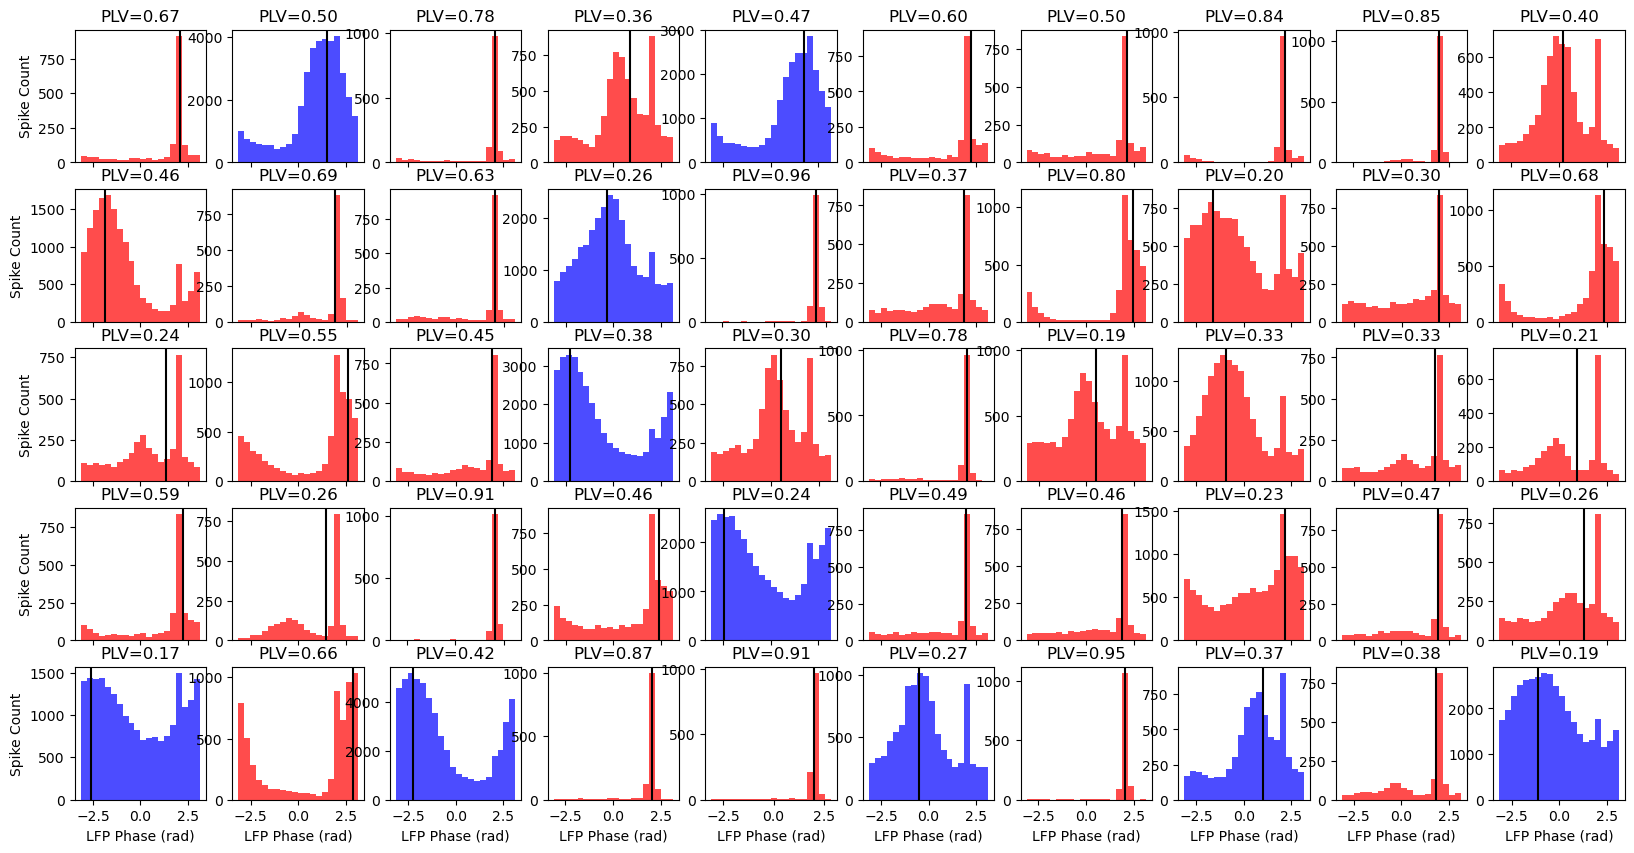

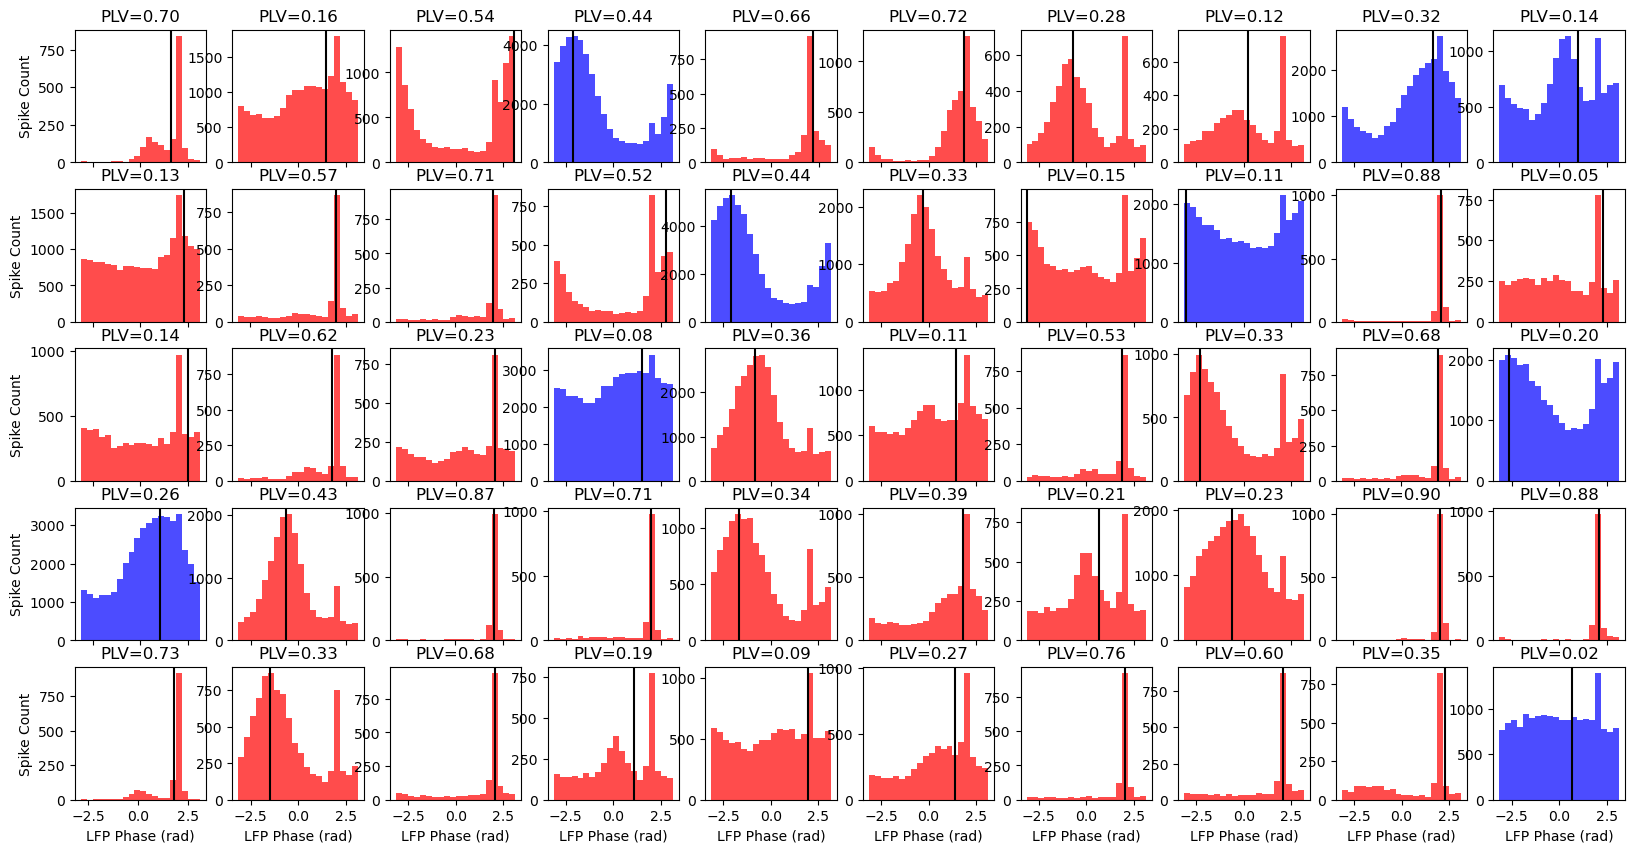

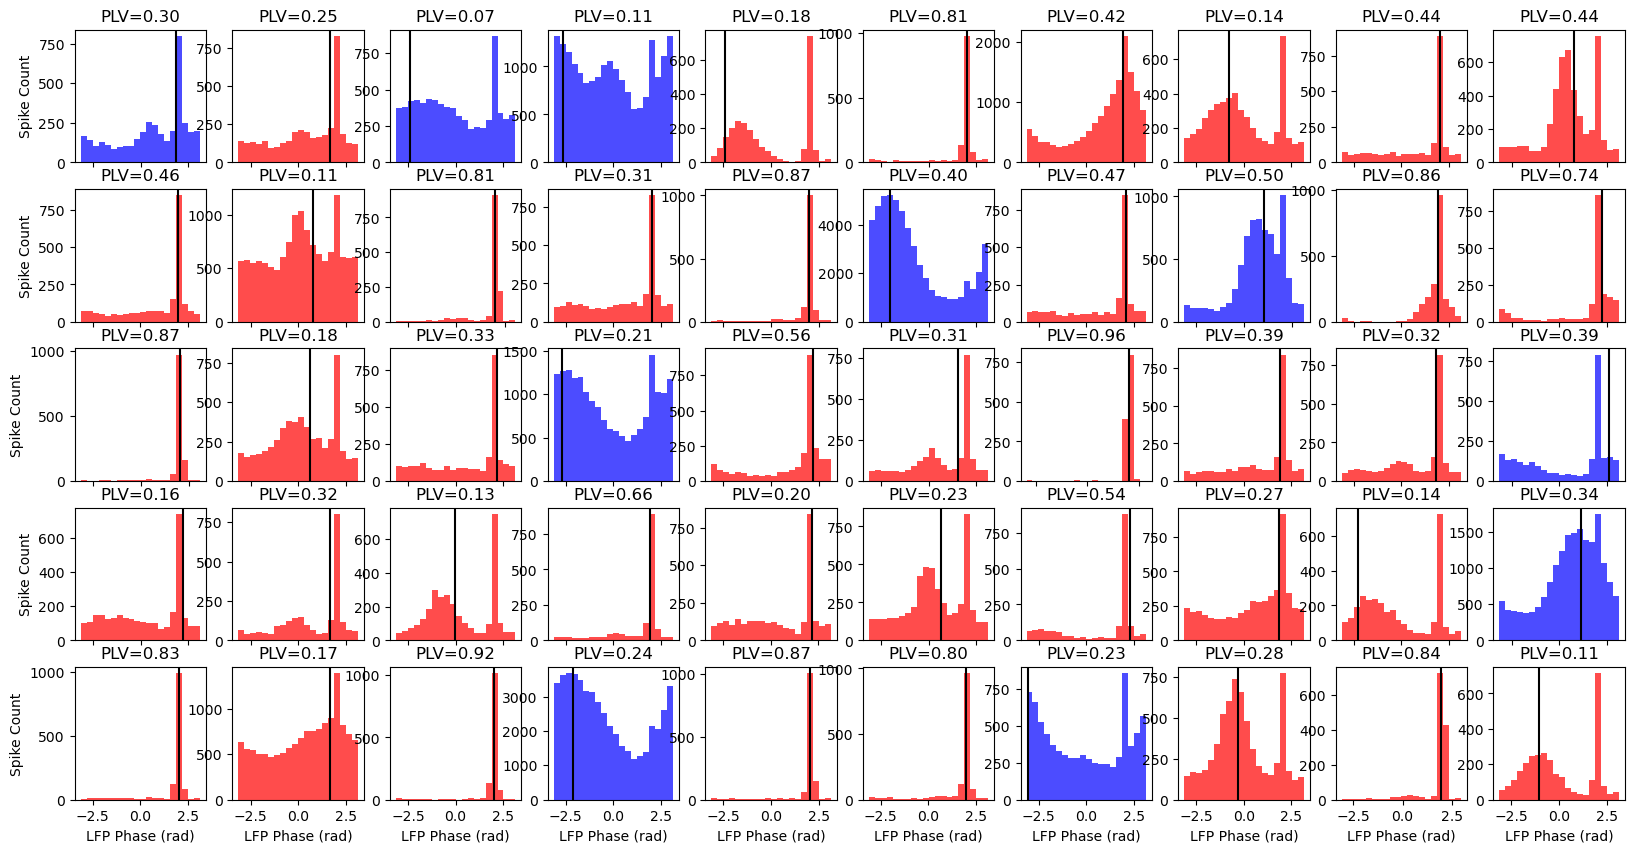

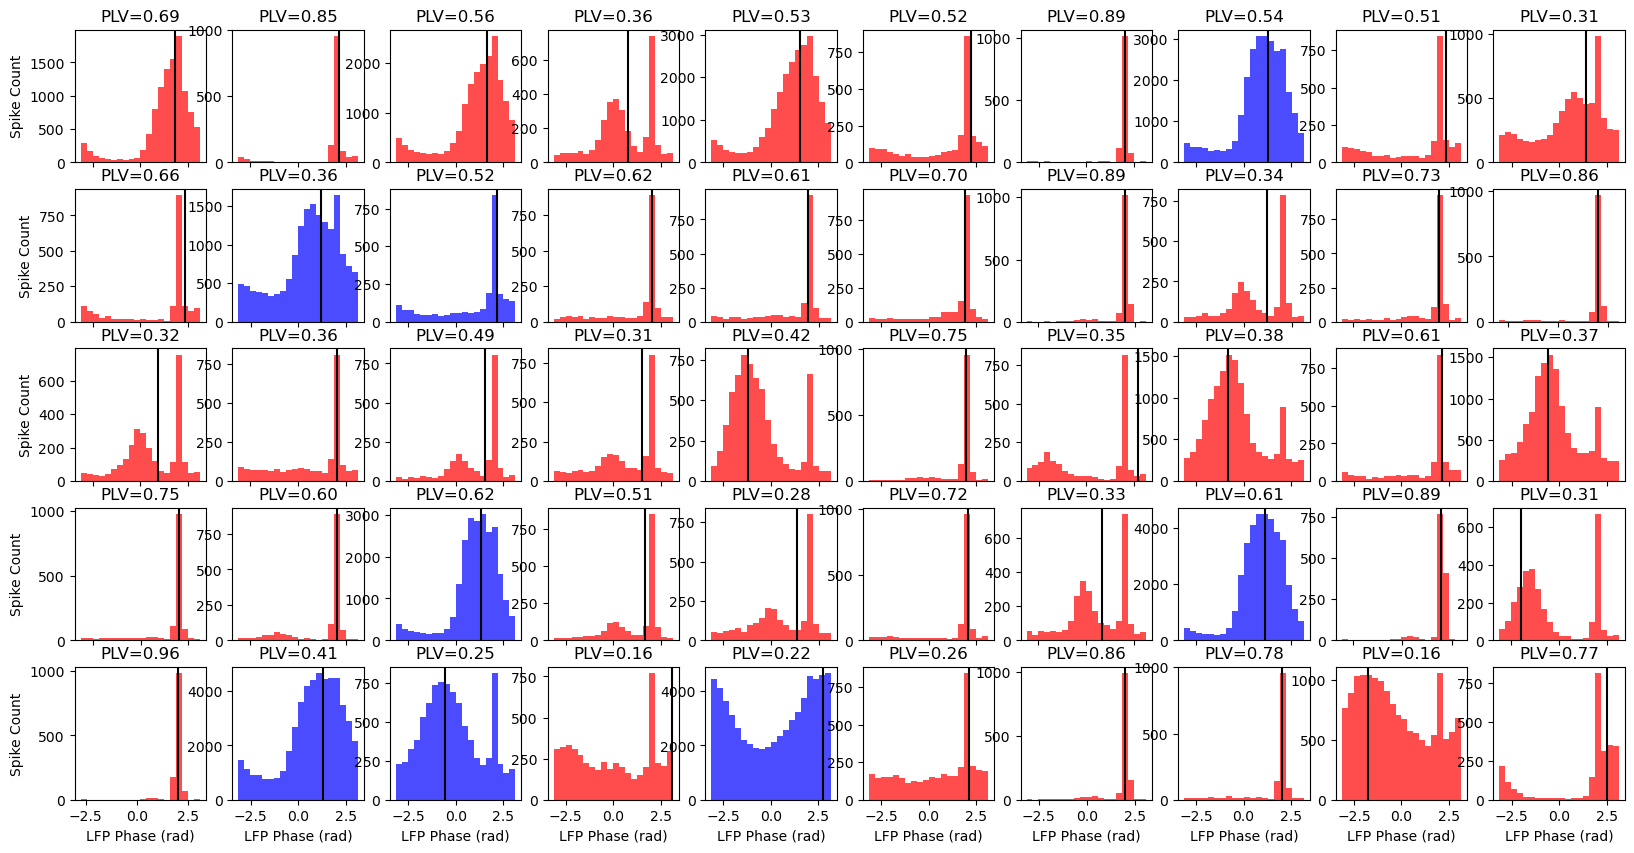

In [87]:
# iterate thru all neurons and plot
neuron_ids = spike_df['cell_id'].unique()

plvs = []
for neuron_id in neuron_ids:
    if neuron_id % 50 == 0:
        fig, axs = plt.subplots(5, 10, figsize=(20, 10))
        axs = axs.flatten()
    
    ax = axs[neuron_id % 50]
    
    neuron_df = spike_df[spike_df['cell_id'] == neuron_id]
    neuron_type = neuron_df['cell_type'].values[0]
    if neuron_type == 'exc':
        c = 'r'
    else:
        c = 'b'
    mean_phase, plv, spike_phases = get_neuron_sfc(neuron_df, phase4, fs_spk=fs_spk, fs_lfp=fs_ds)
    plvs.append(plv)
    
    ax.hist(spike_phases, bins=20, color=c, alpha=0.7)
    ax.axvline(mean_phase, color='k', label='Mean Phase')
    ax.set_title(f'PLV={plv:.2f}')
    if neuron_id % 50 >= 40:
        ax.set_xlabel('LFP Phase (rad)')
    else:
        ax.set_xticklabels('')
    if (neuron_id % 50) % 10 == 0:
        ax.set_ylabel('Spike Count')
    # else:
    #     ax.set_yticklabels('')
    

In [ ]:
colors = ['#6E439A','#2B1644', '#236975','#49BEA3']

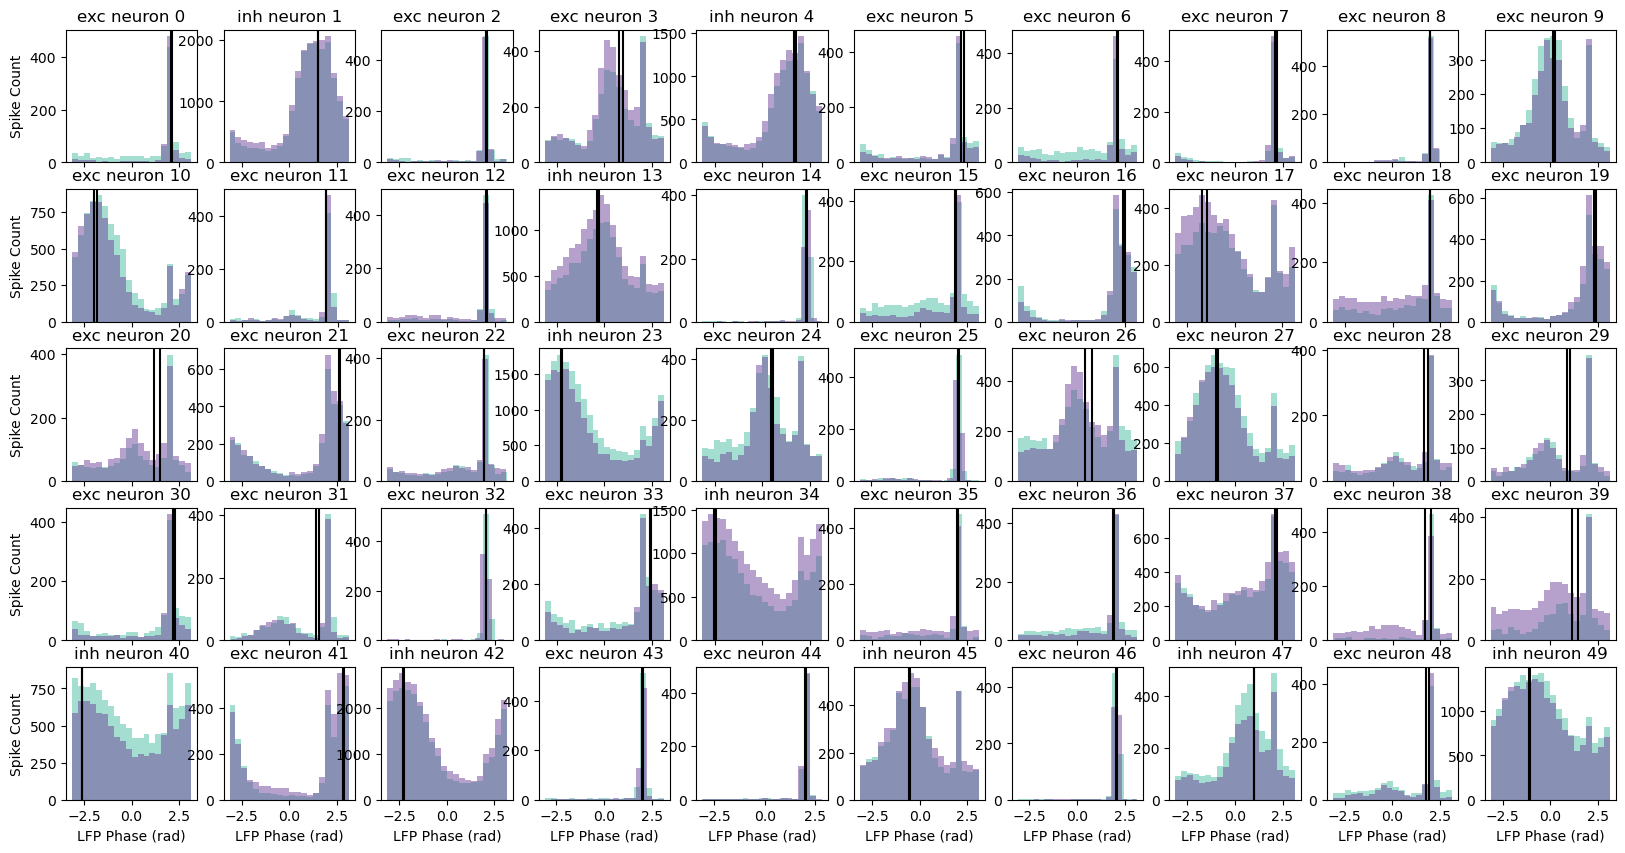

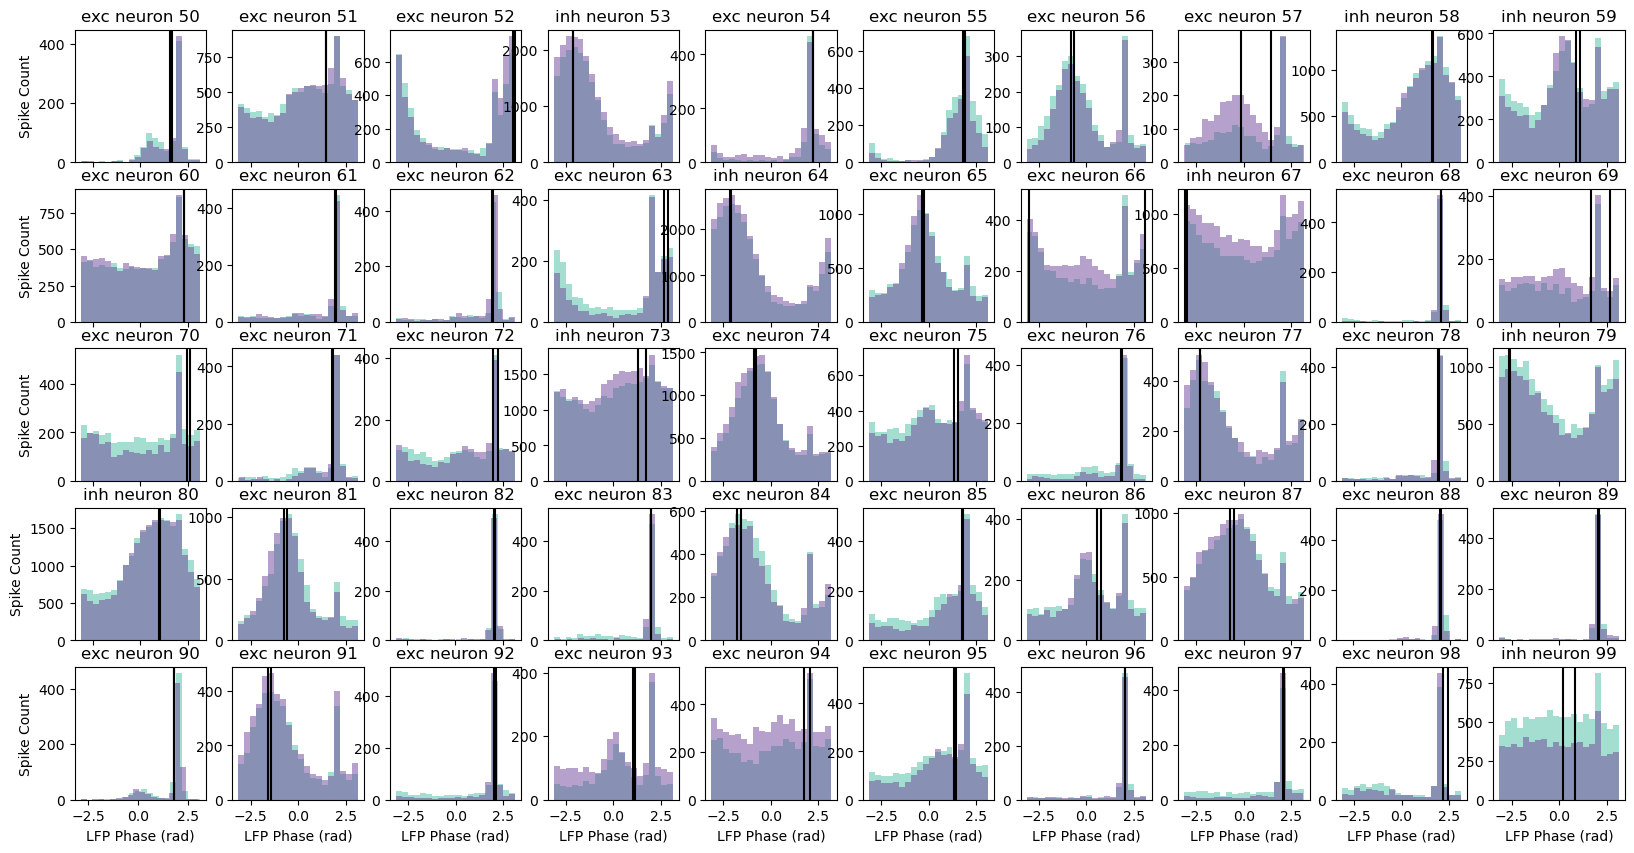

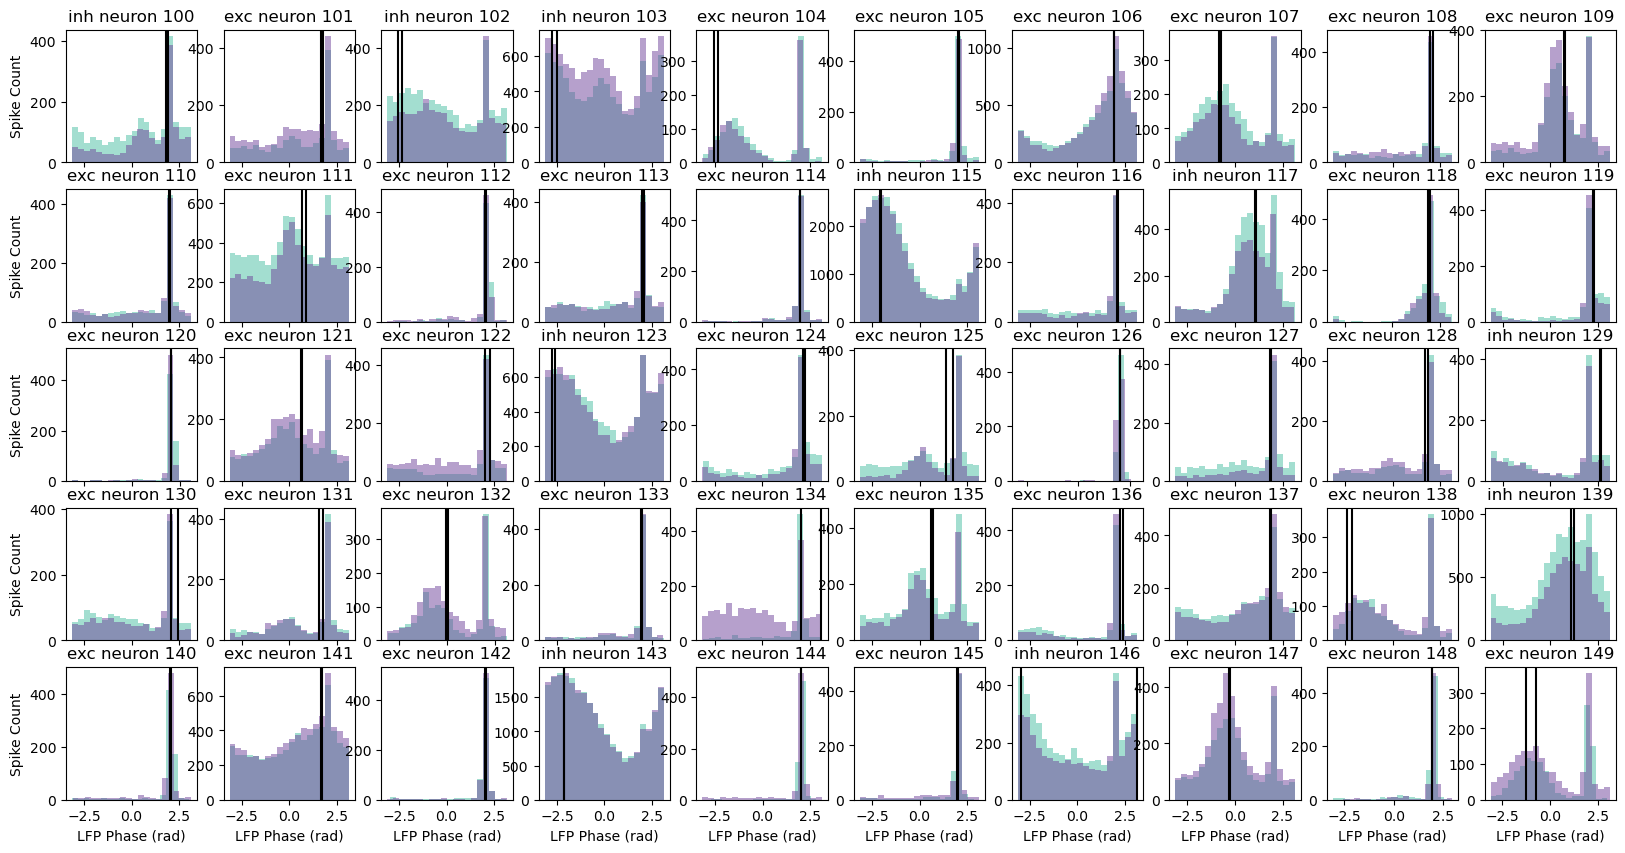

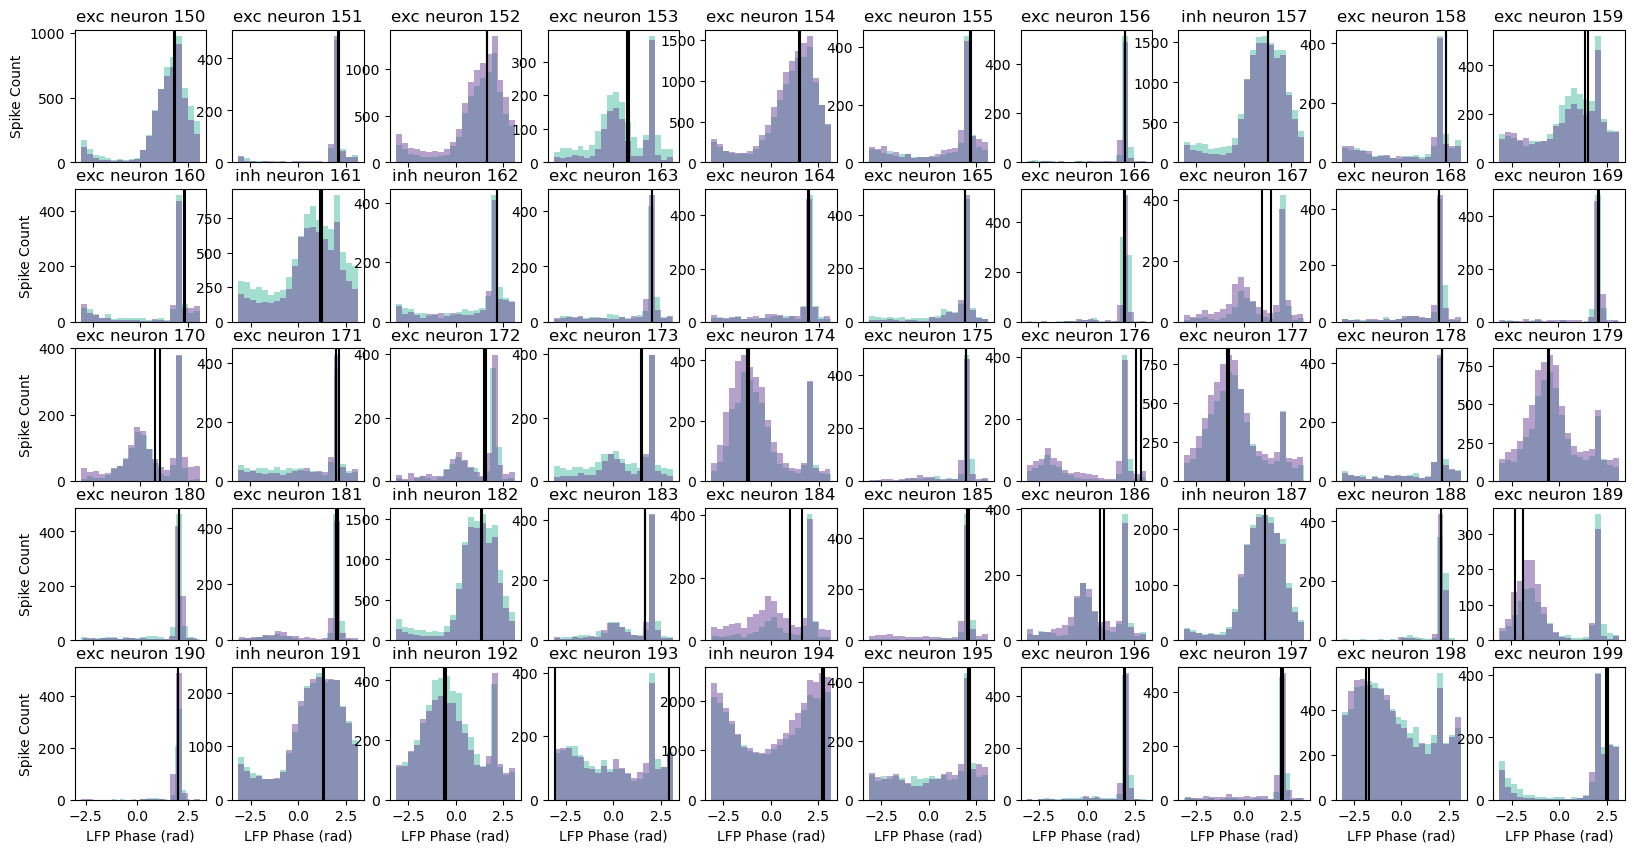

In [ ]:
# iterate thru all neurons and plot
neuron_ids = spike_df['cell_id'].unique()

trial_pos = np.where(trial_labels[:,0] == 1)[0]
trial_neg = np.where(trial_labels[:,0] == -1)[0]

for neuron_id in neuron_ids:
    if neuron_id % 50 == 0:
        fig, axs = plt.subplots(5, 10, figsize=(20, 10))
        axs = axs.flatten()
    
    ax = axs[neuron_id % 50]
    
    neuron_df = spike_df[spike_df['cell_id'] == neuron_id]
    neuron_type = neuron_df['cell_type'].values[0]
    if neuron_type == 'exc':
        c = 'r'
    else:
        c = 'b'
    mean_phase_pos, _, spike_phases_pos = get_neuron_sfc(neuron_df[neuron_df['trial_id'].isin(trial_pos)], phase4, fs_spk=fs_spk, fs_lfp=fs_ds)
    mean_phase_neg, _, spike_phases_neg = get_neuron_sfc(neuron_df[neuron_df['trial_id'].isin(trial_neg)], phase4, fs_spk=fs_spk, fs_lfp=fs_ds)
    
    ax.hist(spike_phases_pos, bins=20, color=colors[3], alpha=0.5)
    ax.hist(spike_phases_neg, bins=20, color=colors[0], alpha=0.5)
    ax.axvline(mean_phase_pos, color='k', label='Mean Phase')
    ax.axvline(mean_phase_neg, color='k', label='Mean Phase')
    ax.set_title(f'{neuron_type} neuron {neuron_id}')
    if neuron_id % 50 >= 40:
        ax.set_xlabel('LFP Phase (rad)')
    else:
        ax.set_xticklabels('')
    if (neuron_id % 50) % 10 == 0:
        ax.set_ylabel('Spike Count')
    # else:
    #     ax.set_yticklabels('')
    

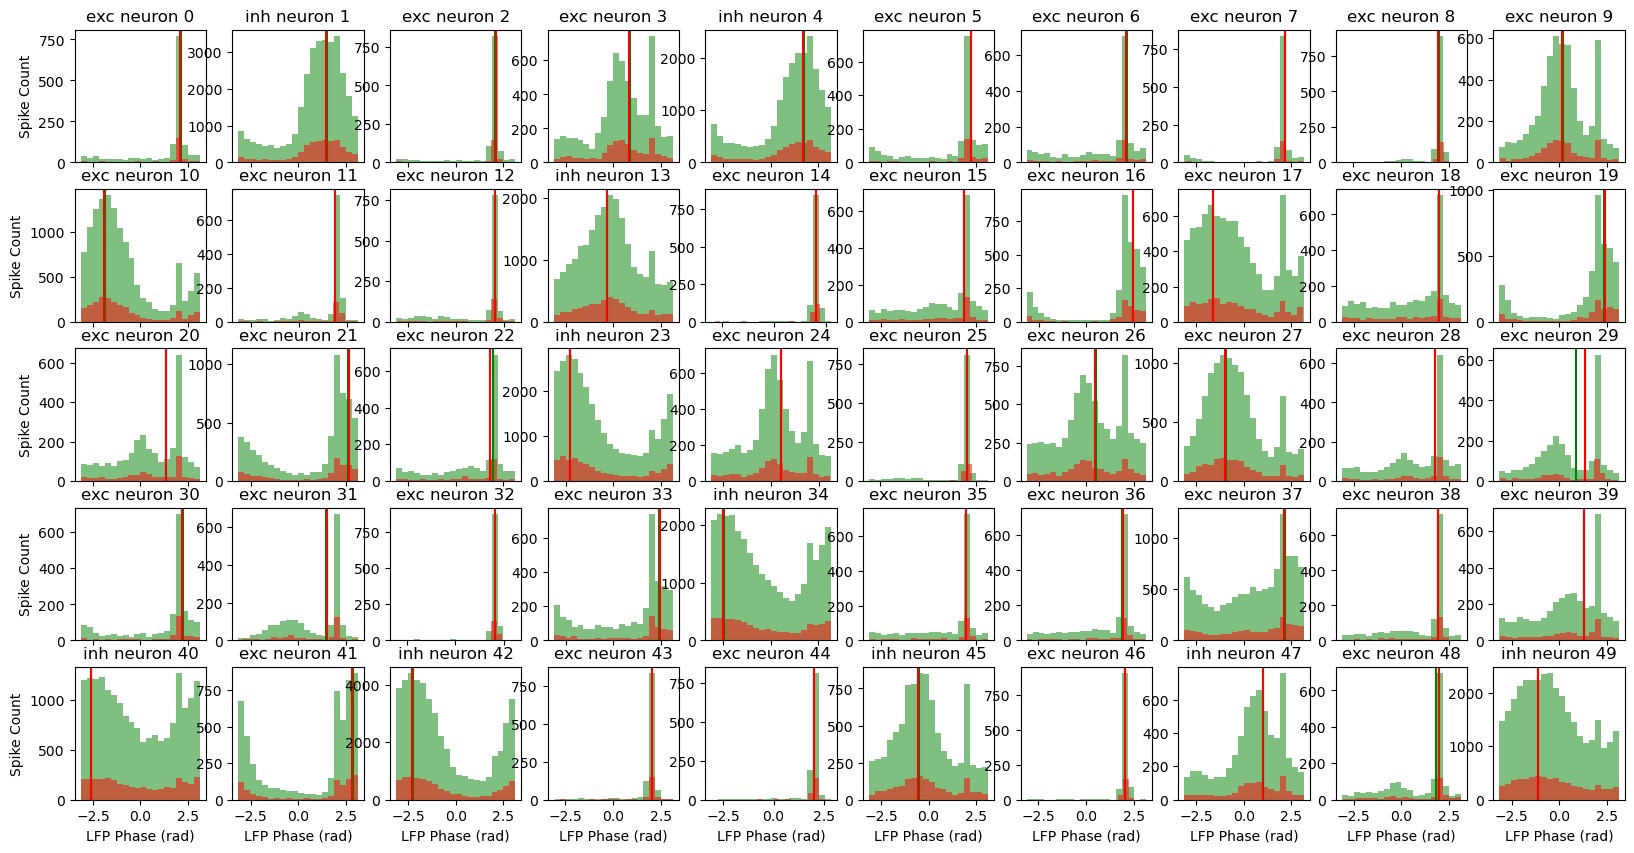

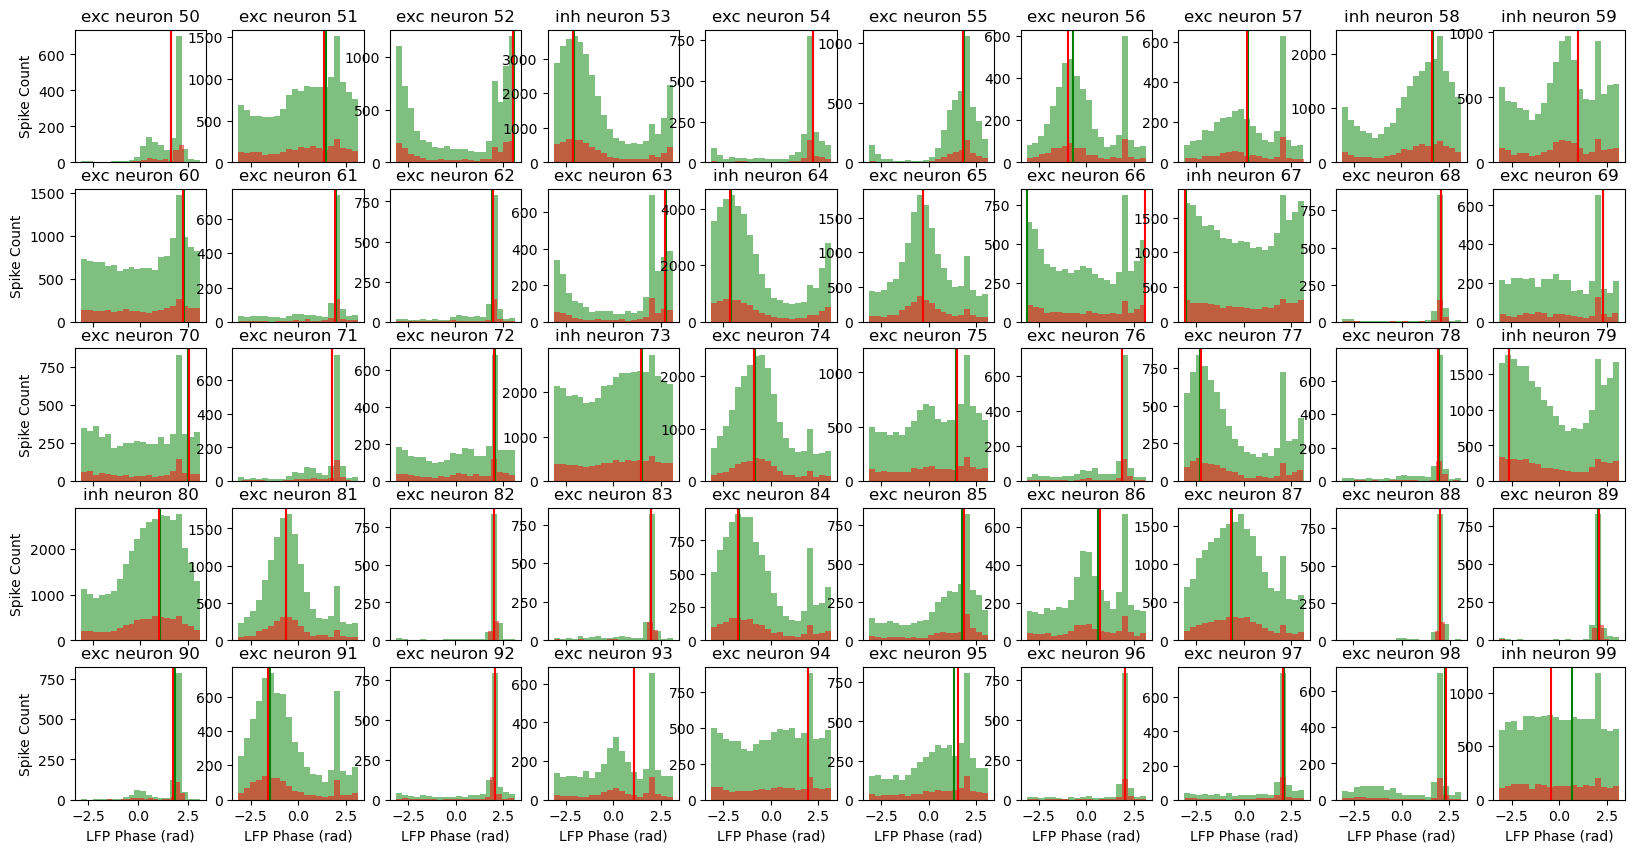

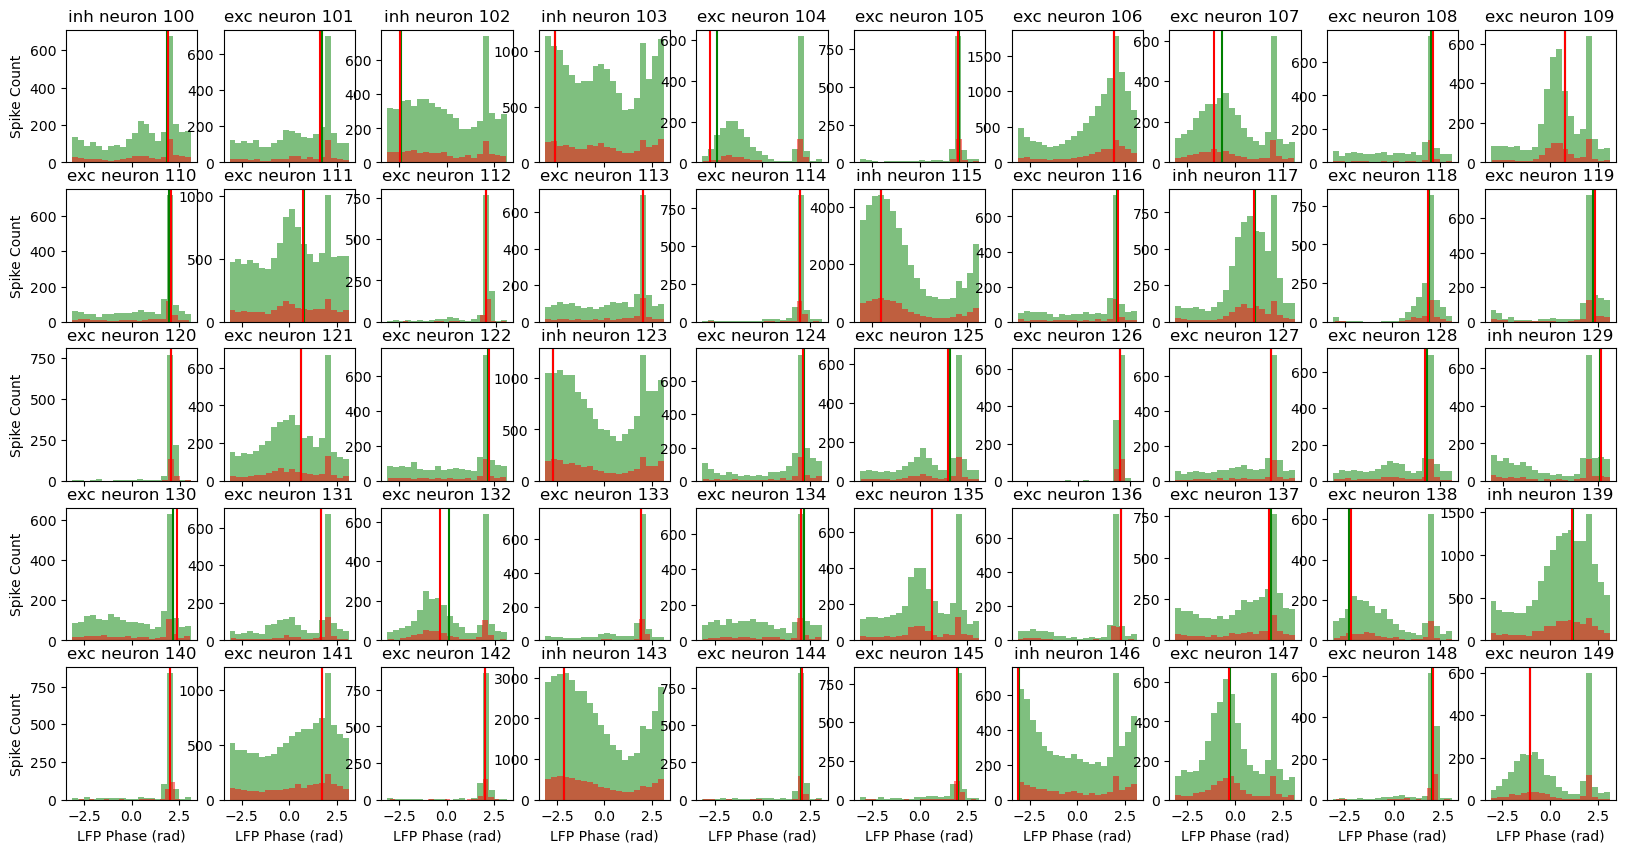

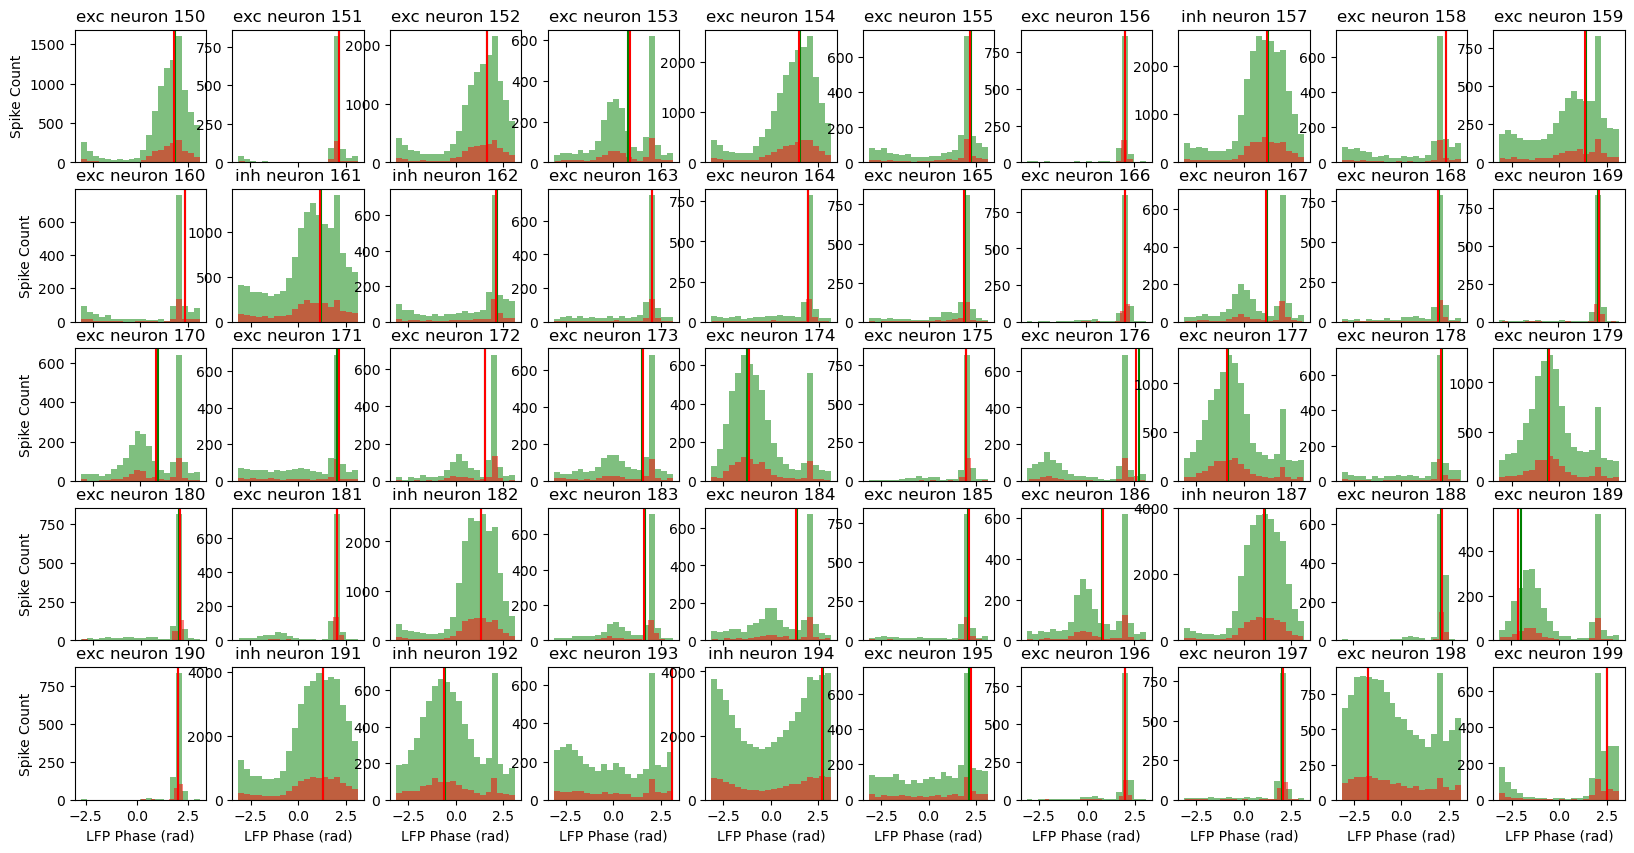

In [104]:
# iterate thru all neurons and plot
neuron_ids = spike_df['cell_id'].unique()

trial_corr = np.where(trial_perfs == 1)[0]
trial_incor = np.where(trial_perfs == 0)[0]

for neuron_id in neuron_ids:
    if neuron_id % 50 == 0:
        fig, axs = plt.subplots(5, 10, figsize=(20, 10))
        axs = axs.flatten()
    
    ax = axs[neuron_id % 50]
    
    neuron_df = spike_df[spike_df['cell_id'] == neuron_id]
    neuron_type = neuron_df['cell_type'].values[0]
    if neuron_type == 'exc':
        c = 'r'
    else:
        c = 'b'
    mean_phase_corr, _, spike_phases_corr = get_neuron_sfc(neuron_df[neuron_df['trial_id'].isin(trial_corr)], phase4, fs_spk=fs_spk, fs_lfp=fs_ds)
    mean_phase_incorr, _, spike_phases_incorr = get_neuron_sfc(neuron_df[neuron_df['trial_id'].isin(trial_incor)], phase4, fs_spk=fs_spk, fs_lfp=fs_ds)
    
    ax.hist(spike_phases_corr, bins=20, color='g', alpha=0.5)
    ax.hist(spike_phases_incorr, bins=20, color='r', alpha=0.5)
    ax.axvline(mean_phase_corr, color='g', label='Mean Phase')
    ax.axvline(mean_phase_incorr, color='r', label='Mean Phase')
    ax.set_title(f'{neuron_type} neuron {neuron_id}')
    if neuron_id % 50 >= 40:
        ax.set_xlabel('LFP Phase (rad)')
    else:
        ax.set_xticklabels('')
    if (neuron_id % 50) % 10 == 0:
        ax.set_ylabel('Spike Count')
    # else:
    #     ax.set_yticklabels('')
    

In [31]:
# function to convert spike times to correct sampling frequency
def convert_spiketimes(spike_df, fs_orig, fs_new):
    spike_df_new = spike_df.copy()
    spike_df_new['spk_times'] = (spike_df['spk_times'] * fs_new / fs_orig)
    return spike_df_new

In [32]:
spike_df_ds = convert_spiketimes(spike_df, fs_orig=int(fs_dict['spk']), fs_new=fs_ds)
spike_df_ds.head()

,cell_id,trial_id,cell_type,spk_times,model_name,delay
0,0,0,exc,[0.0],Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_...,400
1,1,0,inh,"[241.6, 310.6, 355.1, 537.5, 563.35, 589.35, 8...",Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_...,400
2,2,0,exc,[0.0],Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_...,400
3,3,0,exc,"[0.0, 784.6, 1025.35, 2055.95, 3235.65]",Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_...,400
4,4,0,inh,"[9.75, 116.85, 147.1, 187.7, 238.35, 288.35, 3...",Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_...,400


In [34]:
# get phase value for each cell for each trial

# iterate thru spike_df_ds
trial_df = spike_df_ds[spike_df_ds['trial_id'] == 0]
trial_df.head()


,cell_id,trial_id,cell_type,spk_times,model_name,delay
0,0,0,exc,[0.0],Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_...,400
1,1,0,inh,"[241.6, 310.6, 355.1, 537.5, 563.35, 589.35, 8...",Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_...,400
2,2,0,exc,[0.0],Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_...,400
3,3,0,exc,"[0.0, 784.6, 1025.35, 2055.95, 3235.65]",Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_...,400
4,4,0,inh,"[9.75, 116.85, 147.1, 187.7, 238.35, 288.35, 3...",Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_...,400


In [36]:
for i, row in trial_df.iterrows():
    spk_times = np.round(row['spk_times'])
    neuron_id = row['cell_id']
    # get phase values at these spike times
    phase_values = phase[0, :, spk_times.astype(int)]
    print(f'Neuron {neuron_id}, spike times: {spk_times}, phase values: {phase_values}')
    if i == 2:
        break

Neuron 0, spike times: [0.], phase values: [[2.12095946 2.13956076 2.16963643 2.20356492 2.21769653 2.19565099
  2.14110304 2.07315385 2.01796995 1.99141917 1.98412701 1.96867561
  1.93554674 1.89908297 1.86993853 1.8361009  1.78237951 1.71968639
  1.67580692 1.66603634 1.66891545 1.64431528 1.58730101 1.5250926
  1.47317723 1.42401804 1.37259718 1.32324072 1.27392304 1.21185065
  1.13517045 1.06669763 1.03031504 1.02045022 1.00746969 0.97139239
  0.91175545 0.84043745 0.7742707  0.7202272 ]]
Neuron 1, spike times: [ 242.  311.  355.  538.  563.  589.  802.  835.  863. 1048. 1076. 1099.
 1296. 1331. 1366. 1538. 1567. 1589. 1616. 1796. 1828. 1863. 2033. 2067.
 2090. 2282. 2307. 2328. 2371. 2669. 2740.], phase values: [[ 1.7353508   2.35184889  2.96677467 ...  2.62466065  2.64767834
   2.59026051]
 [-2.93539378 -2.05747982 -1.30347947 ...  1.67155812  0.11830397
  -0.48470978]
 [-1.95386141 -0.82531602 -0.01560659 ...  0.94217103  0.98486471
   1.10114338]
 ...
 [ 2.37496588  2.27613794 

In [43]:
neuron_df.head()

,cell_id,trial_id,cell_type,spk_times,model_name,delay
0,0,0,exc,[0.0],Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_...,400
200,0,1,exc,[0.0],Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_...,400
400,0,2,exc,[0.0],Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_...,400
600,0,3,exc,[0.0],Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_...,400
800,0,4,exc,"[0.05, 0.0]",Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_...,400


In [52]:
phase4 = phase[:, 0, :] # (n_trials, n_times)

In [54]:
phase_values = phase4[trial_id, spk_times.astype(int)]

In [55]:
phase_values

array([2.19129149, 2.84627803])

In [51]:
phase[trial_id, 0, spk_times.astype(int)]

array([2.19129149, 2.84627803])

In [56]:
neuron_df = spike_df_ds[spike_df_ds['cell_id'] == 0]

phases = []
for i, row in neuron_df.iterrows():
    spk_times = np.round(row['spk_times'])
    trial_id = row['trial_id']
    # get phase values at these spike times
    phase_values = phase4[trial_id, spk_times.astype(int)]
    phases.extend(phase_values)


(array([ 48.,  37.,  40.,  28.,  26.,  24.,  22.,  14.,  30.,  32.,  26.,
         27.,  25.,  25.,  35., 136., 916., 122.,  54.,  50.]),
 array([-3.13959122e+00, -2.82559876e+00, -2.51160629e+00, -2.19761383e+00,
        -1.88362137e+00, -1.56962891e+00, -1.25563645e+00, -9.41643988e-01,
        -6.27651527e-01, -3.13659066e-01,  3.33395103e-04,  3.14325856e-01,
         6.28318317e-01,  9.42310779e-01,  1.25630324e+00,  1.57029570e+00,
         1.88428816e+00,  2.19828062e+00,  2.51227308e+00,  2.82626555e+00,
         3.14025801e+00]),
 <BarContainer object of 20 artists>)

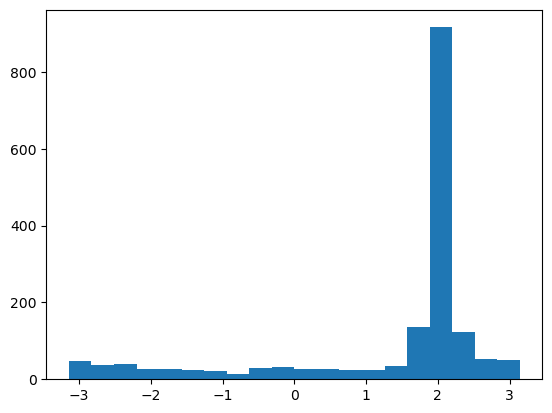

In [58]:
plt.hist(phases, bins=20)